In [1]:
# notebook to see if gains or losses in seqlets over causal variants differ between positive and negatively skewed variants
## update 050526
# see how 3x3s are for:
# active in cell type
# emvar in cell type only

In [1]:
# import packages
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
import pybedtools
from tqdm import tqdm
from scipy import stats
import torch
from collections import Counter
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
import logomaker

In [2]:
# open GTEx DF with all information
allGTEx = pd.read_csv('../processed_data/highPIP_eQTL_mpac_all.tsv.gz', sep = '\t')
# add a mean skew prediction column
allGTEx.loc[:, 'mean_skew_pred'] = [np.mean([k,h,s]) for k,h,s in zip(allGTEx['k562_skew_pred'],
                                                                      allGTEx['hepg2_skew_pred'],
                                                                      allGTEx['sknsh_skew_pred'])]
# add variant_enhancer_phenotype id for groupby
allGTEx.loc[:, 'var_phenoID'] = [('_').join([varID, pheno]) for varID, pheno in zip(allGTEx['variant_id'],
                                                                                    allGTEx['phenotype_id'])]
# add enhancer_variant id for seqlet filtering
allGTEx.loc[:, 'enhVar_id'] = [f'{enhID}_{('_').join(varID.split('_')[0:-1])}' for enhID, varID in zip(allGTEx['enhancer_id'], allGTEx['variant_id'])]

In [3]:
allGTEx.head()

,variant_id,chrom,pos,ref,alt,enhancer_id,lead_tissue,phenotype_id,gene_name,pip,...,k562_tissue_concordant,hepg2_tissue_concordant,sknsh_tissue_concordant,n_gene_associations,n_tissues_significant,cross_tissue_direction_consistent,cross_gene_direction_consistent,mean_skew_pred,var_phenoID,enhVar_id
0,chr1_906982_C_T_b38,chr1,906982,C,T,EH38E2776603,Cells_Cultured_fibroblasts,ENSG00000230699.2,ENSG00000230699,0.999674,...,False,False,False,1,2,True,True,-0.442614,chr1_906982_C_T_b38_ENSG00000230699.2,EH38E2776603_chr1_906982_C_T
1,chr1_906982_C_T_b38,chr1,906982,C,T,EH38E2776603,Esophagus_Mucosa,ENSG00000230699.2,ENSG00000230699,1.000000,...,False,False,False,1,2,True,True,-0.442614,chr1_906982_C_T_b38_ENSG00000230699.2,EH38E2776603_chr1_906982_C_T
2,chr1_930939_G_A_b38,chr1,930939,G,A,EH38E2776655,Brain_Cortex,ENSG00000187583.11,PLEKHN1,0.965329,...,False,False,True,1,1,True,True,-0.002419,chr1_930939_G_A_b38_ENSG00000187583.11,EH38E2776655_chr1_930939_G_A
3,chr1_942951_C_T_b38,chr1,942951,C,T,EH38E2776681,Testis,ENSG00000187634.13,SAMD11,0.952665,...,False,False,False,1,1,True,True,-0.023385,chr1_942951_C_T_b38_ENSG00000187634.13,EH38E2776681_chr1_942951_C_T
4,chr1_973946_C_T_b38,chr1,973946,C,T,EH38E2776737,Pituitary,ENSG00000237973.1,MTCO1P12,0.963338,...,False,False,False,1,1,True,True,-0.055409,chr1_973946_C_T_b38_ENSG00000237973.1,EH38E2776737_chr1_973946_C_T


In [4]:
# define function to add activity/emVar for each cell type
def addActive_emVar (df, actThresh, emVarThresh):
    df2return = df.copy()
    # add activity filter for k562
    df2return.loc[:, 'k562_active'] = [True if max([ref, alt], key=abs) > actThresh else False for ref, alt in zip(df2return['k562_ref_pred'], df2return['k562_alt_pred'])]
    # add activity filter for hepg2
    df2return.loc[:, 'hepg2_active'] = [True if max([ref, alt], key=abs) > actThresh else False for ref, alt in zip(df2return['hepg2_ref_pred'], df2return['hepg2_alt_pred'])]
    # add activity filter for sknsh
    df2return.loc[:, 'sknsh_active'] = [True if max([ref, alt], key=abs) > actThresh else False for ref, alt in zip(df2return['sknsh_ref_pred'], df2return['sknsh_alt_pred'])]
    # add active any
    df2return.loc[:, 'active_any'] = [True if True in [kAct, hAct, sAct] else False for kAct, hAct, sAct in zip(df2return['k562_active'], df2return['hepg2_active'], df2return['sknsh_active'])]
    # add k562 emVar
    df2return.loc[:, 'k562_emVar'] = [True if abs(skew) > emVarThresh else False for skew in df2return['k562_skew_pred']]
    # add hepg2 emVar
    df2return.loc[:, 'hepg2_emVar'] = [True if abs(skew) > emVarThresh else False for skew in df2return['hepg2_skew_pred']]
    # add sknsh emVar
    df2return.loc[:, 'sknsh_emVar'] = [True if abs(skew) > emVarThresh else False for skew in df2return['sknsh_skew_pred']]
    df2return.loc[:, 'emVar_any'] = [True if True in [k,h,s] else False for k,h,s in zip(df2return['k562_emVar'], df2return['hepg2_emVar'], df2return['sknsh_emVar'])]
    
    return df2return 

In [5]:
# add emVar and activity to all GTEx
allGTEx = addActive_emVar(allGTEx, 1, 0.5)

In [6]:
# add tissue any
allGTEx.loc[:,'any_tissue_match'] = [True if True in [k,h,s] else False for k,h,s in zip(allGTEx['k562_tissue_concordant'], allGTEx['hepg2_tissue_concordant'], allGTEx['sknsh_tissue_concordant'])]
# add a nerve only match for SKNSH
allGTEx.loc[:, 'sknsh_nerve_tibial'] = [True if tissue == 'Nerve_Tibial' else False for tissue in allGTEx['lead_tissue']]

In [7]:
# open cCRE bed files and build dELS dict
# k562
k_cCRE = pd.read_csv('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed', sep = '\t', header = None)
k_dELS = k_cCRE[k_cCRE[9] == 'dELS'].copy()
k_dELS_dict = dict(zip(k_dELS[3], k_dELS[9]))
# hepg2
h_cCRE = pd.read_csv('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed', sep = '\t', header = None)
h_dELS = h_cCRE[h_cCRE[9] == 'dELS'].copy()
h_dELS_dict = dict(zip(h_dELS[3], h_dELS[9]))
# sknsh
s_cCRE = pd.read_csv('../raw_data/ENCFF280RMA_ENCFF651WOM_ENCFF262UEH_ENCFF850MLW_SKNSH_cCRE.bed', sep = '\t', header = None)
s_dELS = s_cCRE[s_cCRE[9] == 'dELS'].copy()
s_dELS_dict = dict(zip(s_dELS[3], s_dELS[9]))

In [8]:
# add dELS to df
# k562
allGTEx.loc[:,'k562_dELS'] = [True if i in k_dELS_dict.keys() else False for i in allGTEx['enhancer_id']]
# hepg2
allGTEx.loc[:, 'hepg2_dELS'] = [True if i in h_dELS_dict.keys() else False for i in allGTEx['enhancer_id']]
# sknsh
allGTEx.loc[:, 'sknsh_dELS'] = [True if i in s_dELS_dict.keys() else False for i in allGTEx['enhancer_id']]
# add any
allGTEx.loc[:, 'dELS_any'] = [True if True in [k,h,s] else False for k,h,s in zip(allGTEx['k562_dELS'], allGTEx['hepg2_dELS'], allGTEx['sknsh_dELS'])]

In [9]:
# get some summary stats
print('##### all variant summary #####')
print(f'there are {len(allGTEx['variant_id'].unique())} unique variants')
# emVar rate all variants
print(f'{allGTEx.filter(['variant_id', 'emVar_any']).drop_duplicates()['emVar_any'].sum() / len(allGTEx.filter(['variant_id', 'emVar_any']).drop_duplicates()) * 100:.2f}% of all variants are emVars')
print(f'{allGTEx.filter(['variant_id', 'emVar_any']).drop_duplicates()['emVar_any'].sum()} emVars')
# print the number of active sequences in each cell type
# k562
print(f'there are {allGTEx.filter(['variant_id', 'k562_active']).drop_duplicates()['k562_active'].sum()} active K562 seqeunces')
# hepg2
print(f'there are {allGTEx.filter(['variant_id', 'hepg2_active']).drop_duplicates()['hepg2_active'].sum()} active HepG2 seqeunces')
# sknsh
print(f'there are {allGTEx.filter(['variant_id', 'sknsh_active']).drop_duplicates()['sknsh_active'].sum()} active SKNSH sequences')
# print the number of emVars in each cell type
# k562
print(f'there are {allGTEx.filter(['variant_id', 'k562_emVar']).drop_duplicates()['k562_emVar'].sum()} K562 emVars')
# hepg2
print(f'there are {allGTEx.filter(['variant_id', 'hepg2_emVar']).drop_duplicates()['hepg2_emVar'].sum()} HepG2 emVars')
# sknsh
print(f'there are {allGTEx.filter(['variant_id', 'sknsh_emVar']).drop_duplicates()['sknsh_emVar'].sum()} SKNSH emVars')
# print the number of variants in a cell type matched dELS
print(f'there are {len(allGTEx[allGTEx['dELS_any'] == 1]['variant_id'].unique())} variants in cell type matched enhancers')
# print the emVar rates for those in dELS
print(f'{allGTEx[allGTEx['dELS_any'] == 1].filter(['variant_id', 'emVar_any']).drop_duplicates()['emVar_any'].sum() / len(allGTEx[allGTEx['dELS_any'] == 1].filter(['variant_id', 'emVar_any']).drop_duplicates()) * 100:.2f}% of all dELS variants are emVars')
print(f'{allGTEx[allGTEx['dELS_any'] == 1].filter(['variant_id', 'emVar_any']).drop_duplicates()['emVar_any'].sum()} emVars')

##### all variant summary #####
there are 7367 unique variants
8.85% of all variants are emVars
652 emVars
there are 1935 active K562 seqeunces
there are 2070 active HepG2 seqeunces
there are 1923 active SKNSH sequences
there are 439 K562 emVars
there are 343 HepG2 emVars
there are 418 SKNSH emVars
there are 707 variants in cell type matched enhancers
14.57% of all dELS variants are emVars
103 emVars


In [10]:
# break out variants into relevant DFs
# emVar - All
k562EmVarGTEx = allGTEx[allGTEx['k562_emVar'] == 1].copy()
hepg2EmVarGTEx = allGTEx[allGTEx['hepg2_emVar'] == 1].copy()
sknshEmVarGTEx = allGTEx[allGTEx['sknsh_emVar'] == 1].copy()

In [11]:
# define a function for calculating concordance between mpac predictions and gtex slope
def calcConcordance (df, gtexCol):
    # make a copy of the df to avoid warnings
    df = df.copy()
    # calculate k562 concordance
    df.loc[:, 'k562_gtex_concordance'] = [1 if mpac >= 0 and gtex >= 0 or mpac <= 0 and gtex <= 0 else 0 for mpac, gtex in zip(df['k562_skew_pred'], df[gtexCol])]
    # calcualte hepg2 concordance
    df.loc[:, 'hepg2_gtex_concordance'] = [1 if mpac >= 0 and gtex >= 0 or mpac <= 0 and gtex <= 0 else 0 for mpac, gtex in zip(df['hepg2_skew_pred'], df[gtexCol])]
    # calculate sknsh concordance
    df.loc[:, 'sknsh_gtex_concordance'] = [1 if mpac >= 0 and gtex >= 0 or mpac <= 0 and gtex <= 0 else 0 for mpac, gtex in zip(df['sknsh_skew_pred'], df[gtexCol])]
    # calculate mean concordance
    df.loc[:, 'mean_gtex_concordance'] = [1 if mpac >= 0 and gtex >= 0 or mpac <= 0 and gtex <= 0 else 0 for mpac, gtex in zip(df['mean_skew_pred'], df[gtexCol])]
    # claculate concordance any tissue
    df.loc[:, 'any_concordance'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(df['k562_gtex_concordance'], df['hepg2_gtex_concordance'], df['sknsh_gtex_concordance'])]
    return df

In [12]:
# add concordance to each DF
# All emVar
# k562
k562EmVarGTEx = calcConcordance(
    k562EmVarGTEx,
    'slope'
)
# hepg2
hepg2EmVarGTEx = calcConcordance(
    hepg2EmVarGTEx,
    'slope'
)
# sknsh
sknshEmVarGTEx = calcConcordance(
    sknshEmVarGTEx,
    'slope'
)

In [13]:
# define palette for MPAC cell types
mpacPalette = {
    'k562' : '#00A79D',
    'K562' : '#00A79D',
    'HepG2' : '#FBB040',
    'hepg2' : '#FBB040',
    'HEPG2' : '#FBB040',
    'sknsh' : '#ED1C24',
    'SKNSH' : '#ED1C24',
    'Mean' : '#191970',
    'MEAN' :  '#191970',
    'mean' : '#191970'
}

In [14]:
# define a function to return a BED file for all lead variants for a given cell type
def cellAnnotations (allVars, cell_type):
    # make dictionary of direction of that variant_phenotype pair
    leadVarDirDict = dict(zip(
        allVars['enhVar_id'],
        ['pos' if i > 0 else 'neg' for i in allVars[f'slope']]
    ))
    # add the enhancer_ref
    leadVarRefDirDict = dict(zip(
        [f'{i.split('_')[0]}_REF' for i in allVars['enhVar_id']],
        ['pos' if i > 0 else 'neg' for i in allVars[f'slope']]
    ))
    # combine dictionaries
    leadVarDirDict_full = leadVarDirDict | leadVarRefDirDict
    # break into concordant and discordant direction
    concordantDF = allVars[allVars[f'{cell_type}_gtex_concordance'] == 1].copy()
    discordantDF = allVars[allVars[f'{cell_type}_gtex_concordance'] == 0].copy()
    # make a bed file for concordant variants
    chromBED = []
    startBED = []
    endBED = []
    idBED = []
    for i in concordantDF['enhVar_id']:
        chromBED.append(i.split('_')[1])
        startBED.append(int(i.split('_')[2]) - 1)
        endBED.append(int(i.split('_')[2]))
        idBED.append(i)
    concBED = pd.DataFrame({
        0 : chromBED,
        1 : startBED,
        2 : endBED,
        3 : idBED
    }).drop_duplicates()
    # make a bed file for discordant variants
    chromBED = []
    startBED = []
    endBED = []
    idBED = []
    for i in discordantDF['enhVar_id']:
        chromBED.append(i.split('_')[1])
        startBED.append(int(i.split('_')[2]) - 1)
        endBED.append(int(i.split('_')[2]))
        idBED.append(i)
    discoBED = pd.DataFrame({
        0 : chromBED,
        1 : startBED,
        2 : endBED,
        3 : idBED
    }).drop_duplicates()
    # make it all into a dictionary to be cleaner
    dict2return = {
        'concordantBED' : concBED,
        'discordantBED' : discoBED,
        'leadVarDir' : leadVarDirDict_full,
        'leadVarDirALT' : leadVarDirDict
    }
    return dict2return

In [15]:
# open each seqlet BED file
k562_seqlets = pd.read_csv('../processed_data/alt_background_sat_mut/seqlets_annotated/bed_files/K562_0.01.bed', sep = '\t', header = None)
hepg2_seqlets = pd.read_csv('../processed_data/alt_background_sat_mut/seqlets_annotated/bed_files/HepG2_0.01.bed', sep = '\t', header = None)
sknsh_seqlets = pd.read_csv('../processed_data/alt_background_sat_mut/seqlets_annotated/bed_files/SKNSH_0.01.bed', sep = '\t', header = None)

In [16]:
# make dictionaries of annotations for each cell type
# All emVars
# k562
k562_emVarAnnot = cellAnnotations(
    k562EmVarGTEx,
    'k562'
)
# hepg2
hepg2_emVarAnnot = cellAnnotations(
    hepg2EmVarGTEx,
    'hepg2'
)
# sknsh
sknsh_emVarAnnot = cellAnnotations(
    sknshEmVarGTEx,
    'sknsh'
)

In [17]:
# add CRE start point (for plotting downstream)
cCRE_bed = pd.read_csv('../raw_data/GRCh38-cCREs.bed', sep = '\t', header = None)
# make a dictionary for annotation
cCRE_start_dict = dict(zip(
    cCRE_bed[4],
    cCRE_bed[1]
))

In [18]:
# define a function to add all necessary info to seqlets
def altBackgroundComp (bedDF,
                       annotationDict,
                       cCRE_startDict):
    # get only seqlets that have 'REF' or 'chr' in annotation
    # this is dropping the background seqlets
    filterBool = [i.split('_')[3].startswith('REF') or i.split('_')[3].startswith('chr') for i in bedDF[3]]
    filteredBED = bedDF.loc[filterBool].copy()
    # reformat the DF
    # add TF column
    filteredBED.loc[:, 'tf'] = [('_').join(i.split('_')[:2]) for i in filteredBED[3]]
    # add tf contribution
    filteredBED.loc[:, 'tf_contribution'] = [float(i.split('_')[-1]) for i in filteredBED[3]]
    # add tf direction
    filteredBED.loc[:, 'tf_class'] = ['activator' if float(i.split('_')[-1]) > 0 else 'repressor' for i in filteredBED[3]]
    # add enhancer id
    filteredBED.loc[:, 'enhancer_id'] = [i.split('_')[2] for i in filteredBED[3]]
    # add enhancer start position
    filteredBED.loc[:, 'enhancer_start'] = [cCRE_startDict.get(i) for i in filteredBED['enhancer_id']]
    # add ref/variant annotation
    filteredBED.loc[:, 'background'] = ['REF' if i.split('_')[3] == 'REF' else ('_').join(i.split('_')[3:7]) for i in filteredBED[3]]
    # make a column for filtering
    filteredBED.loc[:, 'filter_id'] = [('_').join([enhID, ann]) for enhID, ann in zip(filteredBED['enhancer_id'], filteredBED['background'])]
    # add variant direction
    # get leadVar annotation
    leadVarDict = annotationDict.get('leadVarDir') 
    # make a dictionary that has ENH_REF
    filteredBED.loc[:, 'leadVar_dir'] = [leadVarDict.get(i) for i in filteredBED['filter_id']]
    # get the concordant and discordant bed files from annotationDict
    # split the seqlets into concordant background seqlets or discordant
    # concordant
    concordantDF = annotationDict['concordantBED']
    # make list of IDs for filtering the full input into discordant/concordant
    concIDs = concordantDF[3].tolist()
    # add REF background
    concIDs = concIDs + [f'{i.split('_')[0]}_REF' for i in concIDs]
    concSeqlets = filteredBED[filteredBED['filter_id'].isin(concIDs)].copy()
    # discordant
    discordantDF = annotationDict['discordantBED']
    # make list of IDs for filtering the full input into discordant/concordant
    discoIDs = discordantDF[3].tolist()
    # add REF background
    discoIDs = discoIDs + [f'{i.split('_')[0]}_REF' for i in discoIDs]
    discoSeqlets = filteredBED[filteredBED['filter_id'].isin(discoIDs)].copy()
    
    # convert concordant/discordant eQTLs to BED
    concordantBED = pybedtools.BedTool.from_dataframe(concordantDF)
    discordantBED = pybedtools.BedTool.from_dataframe(discordantDF)
    # convert the seqlets to a bed
    # concordant
    concSeqletBED = pybedtools.BedTool.from_dataframe(concSeqlets.filter([0,1,2,'filter_id']))
    # discordant
    discoSeqletBED = pybedtools.BedTool.from_dataframe(discoSeqlets.filter([0,1,2,'filter_id']))

    # intersect concordant variants 
    concordantIntersect = concordantBED.intersect(concSeqletBED, wb=True).to_dataframe()
    # intersect discordant variants
    discordantIntersect = discordantBED.intersect(discoSeqletBED, wb=True).to_dataframe()

    # build a column with the seqlet of intersection and the background
    # concordant
    concordantIntersect.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(concordantIntersect['score'],
                                                                                                                                              concordantIntersect['strand'],
                                                                                                                                              concordantIntersect['thickStart'],
                                                                                                                                              concordantIntersect['thickEnd'])]
    # discordant
    discordantIntersect.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(discordantIntersect['score'],
                                                                                                                                              discordantIntersect['strand'],
                                                                                                                                              discordantIntersect['thickStart'],
                                                                                                                                              discordantIntersect['thickEnd'])]
    # turn that into a dictionary for annotating the initial seqlet DF
    # concordant
    concIntersectDict = dict(zip(
        concordantIntersect['intersectSeqlet'],
        [1 for i in range(len(concordantIntersect['intersectSeqlet']))]
    ))
    # discordant
    discoIntersectDict = dict(zip(
        discordantIntersect['intersectSeqlet'],
        [1 for i in range(len(discordantIntersect['intersectSeqlet']))]
    ))
    # add a binary to the df for whether that seqlet intersects the variant
    # add seqlet id for pulling dictionary values
    # concordant
    concSeqlets.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(concSeqlets[0],
                                                                                                                                      concSeqlets[1],
                                                                                                                                      concSeqlets[2],
                                                                                                                                      concSeqlets['filter_id'])]                                                                                                                                     
    concSeqlets.loc[:, 'intersects_leadVar'] = [concIntersectDict.get(i) if i in concIntersectDict.keys() else 0 for i in concSeqlets['intersectSeqlet']]
    # discordant
    discoSeqlets.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(discoSeqlets[0],
                                                                                                                                       discoSeqlets[1],
                                                                                                                                       discoSeqlets[2],
                                                                                                                                       discoSeqlets['filter_id'])]
    discoSeqlets.loc[:, 'intersects_leadVar'] = [discoIntersectDict.get(i) if i in discoIntersectDict.keys() else 0 for i in discoSeqlets['intersectSeqlet']]
    
    # get the distance to nearest seqlet 
    # concordant
    concordantDistance = concordantBED.closest(concSeqletBED, d=True).to_dataframe()
    # check whether the nearest seqlet is within the same enhancer
    concordantDistance.loc[:, 'var_enh'] = [i.split('_')[0] for i in concordantDistance['name']]
    concordantDistance.loc[:, 'nearest_enh'] = [i.split('_')[0] for i in concordantDistance['thickEnd']]
    concordantDistance.loc[:, 'nearest_in_enh'] = [1 if varEnh == closestEnh else 0 for varEnh, closestEnh in zip(concordantDistance['var_enh'],
                                                                                                                  concordantDistance['nearest_enh'])]
    # build dictionaries for annotating df with distance to nearest seqlet
    # add ID
    # concordant
    concordantDistance.loc[:, 'nearestSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(concordantDistance['score'],
                                                                                                                                           concordantDistance['strand'],
                                                                                                                                           concordantDistance['thickStart'],
                                                                                                                                           concordantDistance['thickEnd'])]
    # nearest
    concDistDict = dict(zip(
        concordantDistance['nearestSeqlet'],
        concordantDistance['itemRgb']
    ))
    concSeqlets.loc[:, 'closestSeqlet'] = [1 if i in concDistDict.keys() else 0 for i in concSeqlets['intersectSeqlet']]
    concSeqlets.loc[:, 'dist2leadVar'] = [concDistDict.get(i) if i in concDistDict.keys() else np.nan for i in concSeqlets['intersectSeqlet']]
    # discordant
    discordantDistance = discordantBED.closest(discoSeqletBED, d=True).to_dataframe()
    # check whether nearest seqlet is within the same enhancer
    discordantDistance.loc[:, 'var_enh'] = [i.split('_')[0] for i in discordantDistance['name']]
    discordantDistance.loc[:, 'nearest_enh'] = [i.split('_'[0]) for i in discordantDistance['thickEnd']]
    discordantDistance.loc[:, 'nearest_in_enh'] = [1 if varEnh == closestEnh else 0 for varEnh, closestEnh in zip(discordantDistance['var_enh'],
                                                                                                                  discordantDistance['nearest_enh'])]
    # build dictionaries for annotating df with distance to nearest seqlet
    # add ID
    # concordant
    discordantDistance.loc[:, 'nearestSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(discordantDistance['score'],
                                                                                                                                           discordantDistance['strand'],
                                                                                                                                           discordantDistance['thickStart'],
                                                                                                                                           discordantDistance['thickEnd'])]
    # nearest
    discoDistDict = dict(zip(
        discordantDistance['nearestSeqlet'],
        discordantDistance['itemRgb']
    ))
    discoSeqlets.loc[:, 'closestSeqlet'] = [1 if i in discoDistDict.keys() else 0 for i in discoSeqlets['intersectSeqlet']]
    discoSeqlets.loc[:, 'dist2leadVar'] = [discoDistDict.get(i) if i in discoDistDict.keys() else np.nan for i in discoSeqlets['intersectSeqlet']]                                                                                 
    
    return concSeqlets, discoSeqlets

In [19]:
# define function for calculating seqlet/gain/losses etc for each cell type
def reformat4SeqletOverlap (leadVarSeqlets, concordantBED=None, leadVarDirALT=None):
    # get only the enhancer_leadVar IDs for reformatting
    # drop enh_REF (we can rebuild those)
    noREF = leadVarSeqlets[leadVarSeqlets['background'] != 'REF']
    # make empty lists for building df
    enhVarPair = []
    leadVar = []
    nActivatorsAlt = []
    nActivatorsREF = []
    nRepressorsAlt = []
    nRepressorsREF = []
    activatorContribAlt = []
    activatorContribREF = []
    repressorContribAlt = []
    repressorContribREF = []
    varDir = []
    leadVarInSeqletAlt = []
    leadVarSeqletAltType = []
    leadVarInSeqletREF = []
    leadVarinSeqletREFtype = []
    # iterate through the enhancer lead variant pairs
    for enhVar in tqdm(noREF['filter_id'].unique()):
        # build ref id
        refID = f'{enhVar.split('_')[0]}_REF'
        # filter all seqlets for that enhancer varaint pair
        enhVarSeqlets = leadVarSeqlets[leadVarSeqlets['filter_id'] == enhVar]
        # append enhancer variant pair to list
        enhVarPair.append(enhVar)
        # append lead var to list
        leadVar.append(enhVarSeqlets['background'].tolist()[0])
        # count activators on the alt background
        nActAlt = enhVarSeqlets['tf_class'].tolist().count('activator')
        nActivatorsAlt.append(nActAlt)
        # count repressors on the alt background
        nRepAlt = enhVarSeqlets['tf_class'].tolist().count('repressor')
        nRepressorsAlt.append(nRepAlt)
        # sum activator contribution
        if nActAlt > 0:
            activatorContribAlt.append(enhVarSeqlets[enhVarSeqlets['tf_class'] == 'activator']['tf_contribution'].sum())
        else:
            activatorContribAlt.append(0)
        # sum repressor contribution
        if nRepAlt > 0:
            repressorContribAlt.append(enhVarSeqlets[enhVarSeqlets['tf_class'] == 'repressor']['tf_contribution'].sum())
        else:
            repressorContribAlt.append(0)
        # append leadVar skew direction
        varDir.append(enhVarSeqlets['leadVar_dir'].tolist()[0])
        # check if lead variant intersects a seqlet in that background
        if enhVarSeqlets['intersects_leadVar'].sum() > 0:
            # get the seqlets that intersect the lead variants
            leadVarInSeqletAltDF = enhVarSeqlets[enhVarSeqlets['intersects_leadVar'] == 1].copy()
            leadVarInSeqletAlt.append(1)
            leadVarSeqletAltType.append(leadVarInSeqletAltDF['tf_class'].tolist()[0])
        else:
            leadVarInSeqletAlt.append(0)
            leadVarSeqletAltType.append(0)
        # flter for the appropriate ref background
        enhVarREFBackground = leadVarSeqlets[leadVarSeqlets['filter_id'] == refID].copy()
        # count activators on ref background
        nActREF = enhVarREFBackground['tf_class'].tolist().count('activator')
        nActivatorsREF.append(nActREF)
        # count repressors on ref background
        nRepREF = enhVarREFBackground['tf_class'].tolist().count('repressor')
        nRepressorsREF.append(nRepREF)
        # sum activator contribution
        if nActREF > 0:
            activatorContribREF.append(enhVarREFBackground[enhVarREFBackground['tf_class'] == 'activator']['tf_contribution'].sum())
        else:
            activatorContribREF.append(0)
        # sum repressor contribution
        if nRepREF > 0:
            repressorContribREF.append(enhVarREFBackground[enhVarREFBackground['tf_class'] == 'repressor']['tf_contribution'].sum())
        else:
            repressorContribREF.append(0)
        # check if lead variant intersects a seqlet in that background
        if enhVarREFBackground['intersects_leadVar'].sum() > 0:
            # get the seqlets that intersect the lead variants
            leadVarInSeqletREFdf = enhVarREFBackground[enhVarREFBackground['intersects_leadVar'] == 1].copy()
            leadVarInSeqletREF.append(1)
            leadVarinSeqletREFtype.append(leadVarInSeqletREFdf['tf_class'].tolist()[0])
        else:
            leadVarInSeqletREF.append(0)
            leadVarinSeqletREFtype.append(0)
    # Bug A fix: concordant variants absent from ALT seqlet BED may still overlap a REF seqlet
    # and should be classified as lose_activator / lose_repressor rather than no_seqlet_overlap
    if concordantBED is not None:
        processed = set(noREF['filter_id'].unique())
        refSeqlets = leadVarSeqlets[leadVarSeqlets['background'] == 'REF']
        for enhVar in concordantBED[3].unique():
            if enhVar in processed:
                continue
            refID = f'{enhVar.split('_')[0]}_REF'
            enhVarREFBackground = refSeqlets[refSeqlets['filter_id'] == refID].copy()
            enhVarPair.append(enhVar)
            leadVar.append('_'.join(enhVar.split('_')[1:]))
            varDir.append(leadVarDirALT.get(enhVar) if leadVarDirALT else None)
            nActivatorsAlt.append(0)
            nRepressorsAlt.append(0)
            activatorContribAlt.append(0)
            repressorContribAlt.append(0)
            nActREF = enhVarREFBackground['tf_class'].tolist().count('activator')
            nRepREF = enhVarREFBackground['tf_class'].tolist().count('repressor')
            nActivatorsREF.append(nActREF)
            nRepressorsREF.append(nRepREF)
            activatorContribREF.append(
                enhVarREFBackground[enhVarREFBackground['tf_class'] == 'activator']['tf_contribution'].sum()
                if nActREF > 0 else 0
            )
            repressorContribREF.append(
                enhVarREFBackground[enhVarREFBackground['tf_class'] == 'repressor']['tf_contribution'].sum()
                if nRepREF > 0 else 0
            )
            leadVarInSeqletAlt.append(0)
            leadVarSeqletAltType.append(0)
            # use variant position directly to avoid Bug C contamination from intersects_leadVar flag
            if not enhVarREFBackground.empty:
                var_pos = int(enhVar.split('_')[2])  # 1-based genomic position
                overlap_mask = (enhVarREFBackground[1] <= var_pos - 1) & (enhVarREFBackground[2] > var_pos - 1)
                overlapping = enhVarREFBackground[overlap_mask]
                if len(overlapping) > 0:
                    leadVarInSeqletREF.append(1)
                    leadVarinSeqletREFtype.append(overlapping['tf_class'].tolist()[0])
                else:
                    leadVarInSeqletREF.append(0)
                    leadVarinSeqletREFtype.append(0)
            else:
                leadVarInSeqletREF.append(0)
                leadVarinSeqletREFtype.append(0)
    df2return = pd.DataFrame({
        'enhancer_leadVar_pair' : enhVarPair,
        'leadVariant_id' : leadVar,
        'leadVar_dir' : varDir,
        'n_activators_alt' : nActivatorsAlt,
        'n_activators_ref' : nActivatorsREF,
        'n_repressors_alt' : nRepressorsAlt,
        'n_repressors_ref' : nRepressorsREF,
        'activator_contrib_alt' : activatorContribAlt,
        'activator_contrib_ref' : activatorContribREF,
        'repressor_contrib_alt' : repressorContribAlt,
        'repressor_contrib_ref' : repressorContribREF,
        'leadVariant_in_seqlet_alt' : leadVarInSeqletAlt,
        'leadVariant_in_seqlet_ref' : leadVarInSeqletREF,
        'leadVariant_seqlet_type_alt' : leadVarSeqletAltType,
        'leadVariant_seqlet_type_ref' : leadVarinSeqletREFtype
    })
    return df2return

In [20]:
# define a function for getting the summary of each variant type
def seqletSummaryCount (reformattedSeqlets,
                        groupBED,
                        cellLeadVarDirs,
                        cell_type):
    # split into positive and negative variants
    # +
    posVars = reformattedSeqlets[reformattedSeqlets['leadVar_dir'] == 'pos'].copy()
    # -
    negVars = reformattedSeqlets[reformattedSeqlets['leadVar_dir'] == 'neg'].copy()
    # get group membership from input BED
    pos_in_group = [i for i in groupBED[3] if cellLeadVarDirs.get(i) == 'pos']
    neg_in_group = [i for i in groupBED[3] if cellLeadVarDirs.get(i) == 'neg']
    # get the number of positive variants without any seqlets
    nPosNoSeqletBoth = len([i for i in pos_in_group if i not in posVars['enhancer_leadVar_pair'].tolist()])
    # count the number of activators on the alt background
    nPosActAlt = posVars['leadVariant_seqlet_type_alt'].tolist().count('activator')
    # count the number of repressors on the alt background
    nPosRepAlt = posVars['leadVariant_seqlet_type_alt'].tolist().count('repressor')
    # count the number of no seqlet overlaps on the alt background
    nPosNoSeqAlt = posVars['leadVariant_seqlet_type_alt'].tolist().count(0)
    # count the number of activators on the ref background
    nPosActREF = posVars['leadVariant_seqlet_type_ref'].tolist().count('activator')
    # count the number of repressors on the ref background
    nPosRepREF = posVars['leadVariant_seqlet_type_ref'].tolist().count('repressor')
    # count the number of no seqlet on the ref background
    nPosNoSeqREF = posVars['leadVariant_seqlet_type_ref'].tolist().count(0)
    # build summary
    posVarSummary = pd.DataFrame({
        'background' : ['Ref', 'Alt'],
        'n_no_seqlet' : [nPosNoSeqREF, nPosNoSeqAlt],
        'n_activator_seqlet' : [nPosActREF, nPosActAlt],
        'n_repressor_seqlet' : [nPosRepREF, nPosRepAlt]
    })
    
    # get the number of negative variants without any seqlets
    nNegNoSeqletBoth = len([i for i in neg_in_group if i not in negVars['enhancer_leadVar_pair'].tolist()])
    # count the number of activators on the alt background
    nNegActAlt = negVars['leadVariant_seqlet_type_alt'].tolist().count('activator')
    # count the number of repressors on the alt background
    nNegRepAlt = negVars['leadVariant_seqlet_type_alt'].tolist().count('repressor')
    # count the number of no seqlet overlaps on the alt background
    nNegNoSeqAlt = negVars['leadVariant_seqlet_type_alt'].tolist().count(0)
    # count the number of activators on the ref background
    nNegActREF = negVars['leadVariant_seqlet_type_ref'].tolist().count('activator')
    # count the number of repressors on the ref background
    nNegRepREF = negVars['leadVariant_seqlet_type_ref'].tolist().count('repressor')
    # count the number of no seqlet on the ref background
    nNegNoSeqREF = negVars['leadVariant_seqlet_type_ref'].tolist().count(0)
    # build summary
    negVarSummary = pd.DataFrame({
        'background' : ['Ref', 'Alt'],
        'n_no_seqlet' : [nNegNoSeqREF, nNegNoSeqAlt],
        'n_activator_seqlet' : [nNegActREF, nNegActAlt],
        'n_repressor_seqlet' : [nNegRepREF, nNegRepAlt]
    })
    print(f'{cell_type.upper()}')
    print('positive eQTLs\n')
    print(f'there are {len(posVars) + nPosNoSeqletBoth} positive variant pairs')
    print(f'there are {nPosNoSeqletBoth} variants with no seqlets in either background')
    display(posVarSummary)
    print('negative eQTLs\n')
    print(f'there are {len(negVars) + nNegNoSeqletBoth} negative variant pairs')
    print(f'there are {nNegNoSeqletBoth} variants with no seqlets in either background')
    display(negVarSummary)

In [21]:
# define a helper function for adding eQTL mechanism
def assignMech (varDF):
    # set counts for each mechanism
    NoSeqEither = 0
    GainAct = 0
    GainRep = 0
    LoseAct = 0
    LoseRep = 0
    StrengthenAct = 0
    StrengthenRep = 0
    FlipActivator = 0
    FlipRepressor = 0
    # make a dictionary enhancer var : mechanism dict
    dict2return = {}
    # iterate through features
    for altSeqlet, refSeqlet, altType, refType, enhLeadPair in zip(varDF['leadVariant_in_seqlet_alt'],
                                                                   varDF['leadVariant_in_seqlet_ref'],
                                                                   varDF['leadVariant_seqlet_type_alt'],
                                                                   varDF['leadVariant_seqlet_type_ref'],
                                                                   varDF['enhancer_leadVar_pair']):
        # assign mechanism
        # none/none
        if altSeqlet == 0 and refSeqlet == 0:
            NoSeqEither +=1
            dict2return[enhLeadPair] = 'no_seqlet_overlap'
        # gain alt seqlet
        elif refSeqlet == 0 and altSeqlet == 1:
            if altType == 'activator':
                GainAct +=1
                dict2return[enhLeadPair] = 'gain_activator'
            else:
                GainRep +=1
                dict2return[enhLeadPair] = 'gain_repressor'
        # lose ref seqlet
        elif refSeqlet == 1 and altSeqlet == 0:
            # check loss of activator
            if refType == 'activator':
                LoseAct +=1
                dict2return[enhLeadPair] = 'lose_activator'
            else:
                LoseRep +=1
                dict2return[enhLeadPair] = 'lose_repressor'
        # check instances where there is a seqlet in both ref and alt and if it:
        # strengthens acivator
        # strengthens repressor
        # flips activator
        # flips repressor
        elif refSeqlet == 1 and altSeqlet == 1:
            # strengthens activator
            if refType == 'activator' and altType == 'activator':
                StrengthenAct +=1
                dict2return[enhLeadPair] = 'strengthen_activator'
            # strengthens repressor
            elif refType == 'repressor' and altType == 'repressor':
                StrengthenRep +=1
                dict2return[enhLeadPair] = 'strengthen_repressor'
            # flip activator to repressor
            elif refType == 'activator' and altType == 'repressor':
                FlipActivator +=1
                dict2return[enhLeadPair] = 'flip_act_to_rep'
            # flip repressor to activator
            elif refType == 'repressor' and altType == 'activator':
                FlipRepressor +=1
                dict2return[enhLeadPair] = 'flip_rep_to_act'
    # make a summary DF to return
    summaryDF = pd.DataFrame({
        'no_seqlet_overlap' : [NoSeqEither],
        'gain_activator' : [GainAct],
        'gain_repressor' : [GainRep],
        'lose_activator' : [LoseAct],
        'lose_repressor' : [LoseRep],
        'strengthen_act' : [StrengthenAct],
        'strengthen_rep' : [StrengthenRep],
        'flip_act_to_rep' : [FlipActivator],
        'flip_rep_to_act' : [FlipRepressor]
    })
    return summaryDF, dict2return

In [22]:
# calculate the actual instances of activator gain/repressor gain/strengthen activator/strengthen repressor
def eQTL_mechanism_summary (reformattedSeqlets,
                            groupBED,
                            cellLeadVarDirs,
                            cell_type):
    # split into positive and negative variants
    # +
    posVars = reformattedSeqlets[reformattedSeqlets['leadVar_dir'] == 'pos'].copy()
    # -
    negVars = reformattedSeqlets[reformattedSeqlets['leadVar_dir'] == 'neg'].copy()
    # get varaints in group
    pos_in_group = [i for i in groupBED[3] if cellLeadVarDirs.get(i) == 'pos']
    neg_in_group = [i for i in groupBED[3] if cellLeadVarDirs.get(i) == 'neg']

    # assign mechanism
    posVarSummary, posVarMechanisms = assignMech(posVars)
    negVarSummary, negVarMechanisms = assignMech(negVars)
    
    print(f'{cell_type.upper()}')
    print(f'positive eQTL')
    display(posVarSummary)
    print(f'negative eQTL')
    display(negVarSummary)
    return posVarMechanisms | negVarMechanisms

In [23]:
# define helper function for going from enh:var ID to 3x3 matrix of counts
def dict2matrix (mechanismDict,
                 eQTL_bed):
    # define categories
    noREFnoALT = 0 # no seqlet either
    posREFnoALT = 0 # lose activator
    negREFnoALT = 0 # lose repressor
    noREFposALT = 0 # gain activator
    posREFposALT = 0 # potential strengthen activator
    negREFposALT = 0 # flip repressor to activator
    noREFnegALT = 0 # gain repressor
    posREFnegALT = 0 # flip activator to repressor
    negREFnegALT = 0 # potential strengthen repressor
    # get list of all enh-variant pairs
    for i in eQTL_bed[3]:
        if i not in mechanismDict.keys(): # handles instances where there aren't seqlets at all
            noREFnoALT +=1
        else:
            if mechanismDict.get(i) == 'no_seqlet_overlap':
                noREFnoALT +=1
            elif mechanismDict.get(i) == 'lose_activator':
                posREFnoALT +=1
            elif mechanismDict.get(i) == 'lose_repressor':
                negREFnoALT +=1
            elif mechanismDict.get(i) == 'gain_activator':
                noREFposALT +=1
            elif mechanismDict.get(i) == 'strengthen_activator':
                posREFposALT +=1
            elif mechanismDict.get(i) == 'flip_rep_to_act':
                negREFposALT +=1
            elif mechanismDict.get(i) == 'gain_repressor':
                noREFnegALT +=1
            elif mechanismDict.get(i) == 'flip_act_to_rep':
                posREFnegALT +=1
            elif mechanismDict.get(i) == 'strengthen_repressor':
                negREFnegALT +=1
    # build matrix
    df = pd.DataFrame({
        0 : [noREFnoALT, noREFposALT, noREFnegALT],
        1 : [posREFnoALT, posREFposALT, posREFnegALT],
        2 : [negREFnoALT, negREFposALT, negREFnegALT]
    }).T
    return df

In [24]:
# define a function to add all necessary info to seqlets
def altBackgroundCompPad (bedDF,
                       annotationDict,
                       cCRE_startDict,
                       pad):
    # get only seqlets that have 'REF' or 'chr' in annotation
    # this is dropping the background seqlets
    filterBool = [i.split('_')[3].startswith('REF') or i.split('_')[3].startswith('chr') for i in bedDF[3]]
    filteredBED = bedDF.loc[filterBool].copy()
    # reformat the DF
    # add TF column
    filteredBED.loc[:, 'tf'] = [('_').join(i.split('_')[:2]) for i in filteredBED[3]]
    # add tf contribution
    filteredBED.loc[:, 'tf_contribution'] = [float(i.split('_')[-1]) for i in filteredBED[3]]
    # add tf direction
    filteredBED.loc[:, 'tf_class'] = ['activator' if float(i.split('_')[-1]) > 0 else 'repressor' for i in filteredBED[3]]
    # add enhancer id
    filteredBED.loc[:, 'enhancer_id'] = [i.split('_')[2] for i in filteredBED[3]]
    # add enhancer start position
    filteredBED.loc[:, 'enhancer_start'] = [cCRE_startDict.get(i) for i in filteredBED['enhancer_id']]
    # add ref/variant annotation
    filteredBED.loc[:, 'background'] = ['REF' if i.split('_')[3] == 'REF' else ('_').join(i.split('_')[3:7]) for i in filteredBED[3]]
    # make a column for filtering
    filteredBED.loc[:, 'filter_id'] = [('_').join([enhID, ann]) for enhID, ann in zip(filteredBED['enhancer_id'], filteredBED['background'])]
    # add variant direction
    # get leadVar annotation
    leadVarDict = annotationDict.get('leadVarDir') 
    # make a dictionary that has ENH_REF
    filteredBED.loc[:, 'leadVar_dir'] = [leadVarDict.get(i) for i in filteredBED['filter_id']]
    # get the concordant and discordant bed files from annotationDict
    # split the seqlets into concordant background seqlets or discordant
    # concordant
    concordantDF = annotationDict['concordantBED'].copy()
    # make list of IDs for filtering the full input into discordant/concordant
    concIDs = concordantDF[3].tolist()
    # add REF background
    concIDs = concIDs + [f'{i.split('_')[0]}_REF' for i in concIDs]
    concSeqlets = filteredBED[filteredBED['filter_id'].isin(concIDs)].copy()
    # add the pad
    concSeqlets.loc[:, 1] = [int(i) - pad for i in concSeqlets[1]]
    concSeqlets.loc[:, 2] = [int(i) + pad for i in concSeqlets[2]]
    # discordant
    discordantDF = annotationDict['discordantBED'].copy()
    # make list of IDs for filtering the full input into discordant/concordant
    discoIDs = discordantDF[3].tolist()
    # add REF background
    discoIDs = discoIDs + [f'{i.split('_')[0]}_REF' for i in discoIDs]
    discoSeqlets = filteredBED[filteredBED['filter_id'].isin(discoIDs)].copy()
    # add the pad
    discoSeqlets.loc[:, 1] = [int(i) - pad for i in discoSeqlets[1]]
    discoSeqlets.loc[:, 2] = [int(i) + pad for i in discoSeqlets[2]]
    # convert concordant/discordant eQTLs to BED
    concordantBED = pybedtools.BedTool.from_dataframe(concordantDF)
    discordantBED = pybedtools.BedTool.from_dataframe(discordantDF)
    # convert the seqlets to a bed
    # concordant
    concSeqletBED = pybedtools.BedTool.from_dataframe(concSeqlets.filter([0,1,2,'filter_id']))
    # discordant
    discoSeqletBED = pybedtools.BedTool.from_dataframe(discoSeqlets.filter([0,1,2,'filter_id']))

    # intersect concordant variants 
    concordantIntersect = concordantBED.intersect(concSeqletBED, wb=True).to_dataframe()
    # intersect discordant variants
    discordantIntersect = discordantBED.intersect(discoSeqletBED, wb=True).to_dataframe()

    # build a column with the seqlet of intersection and the background
    # concordant
    concordantIntersect.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(concordantIntersect['score'],
                                                                                                                                              concordantIntersect['strand'],
                                                                                                                                              concordantIntersect['thickStart'],
                                                                                                                                              concordantIntersect['thickEnd'])]
    # discordant
    discordantIntersect.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(discordantIntersect['score'],
                                                                                                                                              discordantIntersect['strand'],
                                                                                                                                              discordantIntersect['thickStart'],
                                                                                                                                              discordantIntersect['thickEnd'])]
    # turn that into a dictionary for annotating the initial seqlet DF
    # concordant
    concIntersectDict = dict(zip(
        concordantIntersect['intersectSeqlet'],
        [1 for i in range(len(concordantIntersect['intersectSeqlet']))]
    ))
    # discordant
    discoIntersectDict = dict(zip(
        discordantIntersect['intersectSeqlet'],
        [1 for i in range(len(discordantIntersect['intersectSeqlet']))]
    ))
    # add a binary to the df for whether that seqlet intersects the variant
    # add seqlet id for pulling dictionary values
    # concordant
    concSeqlets.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(concSeqlets[0],
                                                                                                                                      concSeqlets[1],
                                                                                                                                      concSeqlets[2],
                                                                                                                                      concSeqlets['filter_id'])]                                                                                                                                     
    concSeqlets.loc[:, 'intersects_leadVar'] = [concIntersectDict.get(i) if i in concIntersectDict.keys() else 0 for i in concSeqlets['intersectSeqlet']]
    # discordant
    discoSeqlets.loc[:, 'intersectSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(discoSeqlets[0],
                                                                                                                                       discoSeqlets[1],
                                                                                                                                       discoSeqlets[2],
                                                                                                                                       discoSeqlets['filter_id'])]
    discoSeqlets.loc[:, 'intersects_leadVar'] = [discoIntersectDict.get(i) if i in discoIntersectDict.keys() else 0 for i in discoSeqlets['intersectSeqlet']]
    
    # get the distance to nearest seqlet 
    # concordant
    concordantDistance = concordantBED.closest(concSeqletBED, d=True).to_dataframe()
    # check whether the nearest seqlet is within the same enhancer
    concordantDistance.loc[:, 'var_enh'] = [i.split('_')[0] for i in concordantDistance['name']]
    concordantDistance.loc[:, 'nearest_enh'] = [i.split('_')[0] for i in concordantDistance['thickEnd']]
    concordantDistance.loc[:, 'nearest_in_enh'] = [1 if varEnh == closestEnh else 0 for varEnh, closestEnh in zip(concordantDistance['var_enh'],
                                                                                                                  concordantDistance['nearest_enh'])]
    # build dictionaries for annotating df with distance to nearest seqlet
    # add ID
    # concordant
    concordantDistance.loc[:, 'nearestSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(concordantDistance['score'],
                                                                                                                                           concordantDistance['strand'],
                                                                                                                                           concordantDistance['thickStart'],
                                                                                                                                           concordantDistance['thickEnd'])]
    # nearest
    concDistDict = dict(zip(
        concordantDistance['nearestSeqlet'],
        concordantDistance['itemRgb']
    ))
    concSeqlets.loc[:, 'closestSeqlet'] = [1 if i in concDistDict.keys() else 0 for i in concSeqlets['intersectSeqlet']]
    concSeqlets.loc[:, 'dist2leadVar'] = [concDistDict.get(i) if i in concDistDict.keys() else np.nan for i in concSeqlets['intersectSeqlet']]
    # discordant
    discordantDistance = discordantBED.closest(discoSeqletBED, d=True).to_dataframe()
    # check whether nearest seqlet is within the same enhancer
    discordantDistance.loc[:, 'var_enh'] = [i.split('_')[0] for i in discordantDistance['name']]
    discordantDistance.loc[:, 'nearest_enh'] = [i.split('_'[0]) for i in discordantDistance['thickEnd']]
    discordantDistance.loc[:, 'nearest_in_enh'] = [1 if varEnh == closestEnh else 0 for varEnh, closestEnh in zip(discordantDistance['var_enh'],
                                                                                                                  discordantDistance['nearest_enh'])]
    # build dictionaries for annotating df with distance to nearest seqlet
    # add ID
    # concordant
    discordantDistance.loc[:, 'nearestSeqlet'] = [('_').join([chrom, str(start), str(end), varPair]) for chrom, start, end, varPair in zip(discordantDistance['score'],
                                                                                                                                           discordantDistance['strand'],
                                                                                                                                           discordantDistance['thickStart'],
                                                                                                                                           discordantDistance['thickEnd'])]
    # nearest
    discoDistDict = dict(zip(
        discordantDistance['nearestSeqlet'],
        discordantDistance['itemRgb']
    ))
    discoSeqlets.loc[:, 'closestSeqlet'] = [1 if i in discoDistDict.keys() else 0 for i in discoSeqlets['intersectSeqlet']]
    discoSeqlets.loc[:, 'dist2leadVar'] = [discoDistDict.get(i) if i in discoDistDict.keys() else np.nan for i in discoSeqlets['intersectSeqlet']]                                                                                 
    
    return concSeqlets, discoSeqlets

In [25]:
# define a function for generating the 3x3 matrix of seqlet gain/loss/etc.
def threeByMechanismFlank (mechanismDict, 
                      eQTL_bed,
                      varDirDict,
                      cell_type,
                      cmap):
    # get positive direction eQTLs
    pos_eQTLs = [i for i in varDirDict.keys() if varDirDict.get(i) == 'pos']
    # get negative direction eQTLs
    neg_eQTLs = [i for i in varDirDict.keys() if varDirDict.get(i) == 'neg']
    # filter full eQTL bed for into positive and negative eQTLs
    # neg
    neg_eQTL_bed = eQTL_bed[eQTL_bed[3].isin(neg_eQTLs)].copy()
    # pos
    pos_eQTL_bed = eQTL_bed[eQTL_bed[3].isin(pos_eQTLs)].copy()
    # build matrices
    # pos
    posMatrix = dict2matrix(
        mechanismDict,
        pos_eQTL_bed
    )
    # neg
    negMatrix = dict2matrix(
        mechanismDict,
        neg_eQTL_bed
    )
    # plot it scott
    f = plt.figure(figsize = (6,3), dpi = 300)
    gs = f.add_gridspec(1,2)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    # plot positive eQTLs #
    with sns.axes_style('ticks'):
        ax01 = f.add_subplot(gs[0,0])
        ax01.set_box_aspect(1)
        sns.heatmap(
            posMatrix,
            cmap=cmap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 8},
            cbar=False
        )
        plt.title(f'{cell_type.upper()} Positive eQTLs n={len(pos_eQTL_bed)}', fontsize = 10, loc='left')
        ax01.set_xticks([0.5,1.5,2.5], ['No ALT', 'Act. ALT', 'Rep. ALT'])
        ax01.set_yticks([0.5,1.5,2.5], ['No REF', 'Act. REF', 'Rep. REF'])
    # plot negative eQTLs #
    with sns.axes_style('ticks'):
        ax02 = f.add_subplot(gs[0,1])
        ax02.set_box_aspect(1)
        sns.heatmap(
            negMatrix,
            cmap=cmap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 8},
            cbar=False
        )
        plt.title(f'{cell_type.upper()} Negative eQTLs n={len(neg_eQTL_bed)}', fontsize = 10, loc='left')
        ax02.set_xticks([0.5,1.5,2.5], ['No ALT', 'Act. ALT', 'Rep. ALT'])
        ax02.set_yticks([], [])
    plt.show()
    plt.close()
    return posMatrix, negMatrix

In [30]:
# let's look into the flanks # 
def plotTheFlank(AllSeqlets,
                 AnnotDict,
                 cCRE_start_dict,
                 cell_type,
                 pad,
                 cmap):
    # generate the concordant/discordant seqlet files
    concSeqlets, discoSeqlets = altBackgroundCompPad(
        AllSeqlets,
        AnnotDict,
        cCRE_start_dict,
        pad
    )
    # reformat seqlets 
    # concordant
    concSeqlets4analysis = reformat4SeqletOverlap(concSeqlets, 
                                                  AnnotDict['concordantBED'], 
                                                  AnnotDict['leadVarDirALT'])
    # discordant
    discoSeqlets4analysis = reformat4SeqletOverlap(discoSeqlets,
                                                   AnnotDict['discordantBED'],
                                                   AnnotDict['leadVarDirALT'])
    # build mechansism dict
    # return a dictionary for making the matrices
    # concordant
    concMechDict = eQTL_mechanism_summary(
        concSeqlets4analysis,
        AnnotDict['concordantBED'],
        AnnotDict['leadVarDirALT'],
        cell_type
    )
    # discordant
    discoMechDict = eQTL_mechanism_summary(
        discoSeqlets4analysis,
        AnnotDict['discordantBED'],
        AnnotDict['leadVarDirALT'],
        cell_type
    )
    # plot
    # concordant
    print(f'{cell_type.upper()} Concordant | {pad}bp pad')
    concPosMatrix, concNegMatrix = threeByMechanismFlank(
        concMechDict,
        AnnotDict['concordantBED'],
        AnnotDict['leadVarDirALT'],
        cell_type,
        cmap
    )
    print(f'{cell_type.upper()} Discordant | {pad}bp pad')
    discoPosMatrix, disocNegMatrix = threeByMechanismFlank(
        discoMechDict,
        AnnotDict['discordantBED'],
        AnnotDict['leadVarDirALT'],
        cell_type,
        cmap
    )
    dict2return = {'concordant_seqlets' : concSeqlets,
                   'discordant_seqlets' : discoSeqlets,
                   'concordant_seqlets4analysis' : concSeqlets4analysis,
                   'discordant_seqlets4analysis' : discoSeqlets4analysis,
                   'concordant_mech_dict' : concMechDict,
                   'discordant_mech_dict' : discoMechDict,
                   'concordant_posMatrix' : concPosMatrix,
                   'concordant_negMatrix' : concNegMatrix,
                   'discordant_posMatrix' : discoPosMatrix,
                   'discoradant_negMatrix' : disocNegMatrix}
    return dict2return

100%|██████████| 118/118 [00:00<00:00, 432.88it/s]

K562
positive eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,45,54,0,0,27,4,1,0,9


negative eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,66,1,28,55,2,0,1,15,0


K562
positive eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,33,1,15,21,0,0,2,6,0


negative eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,22,18,0,3,21,1,0,0,1


K562 Concordant | 0bp pad


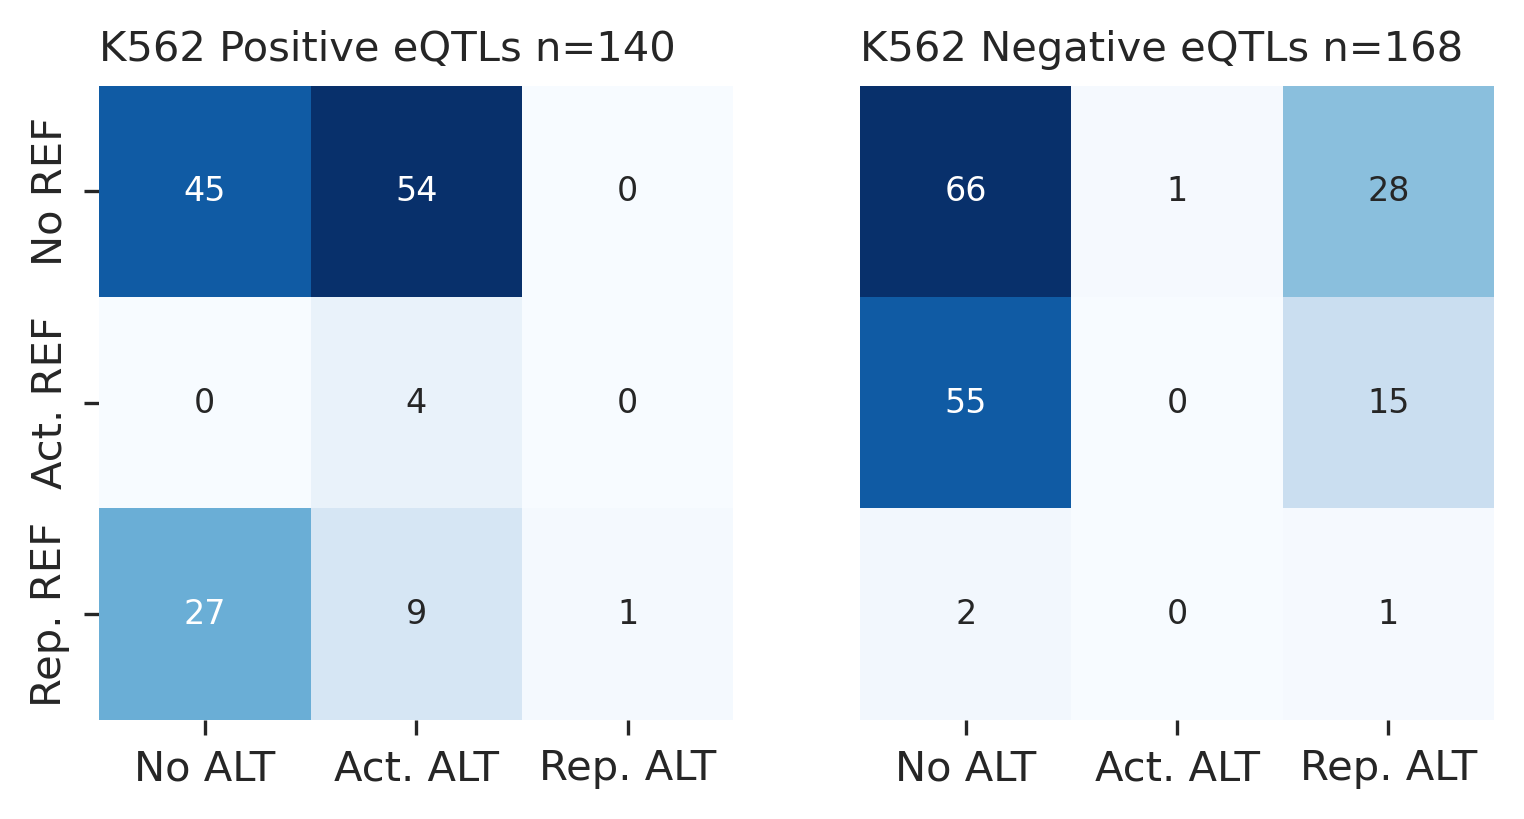

K562 Discordant | 0bp pad


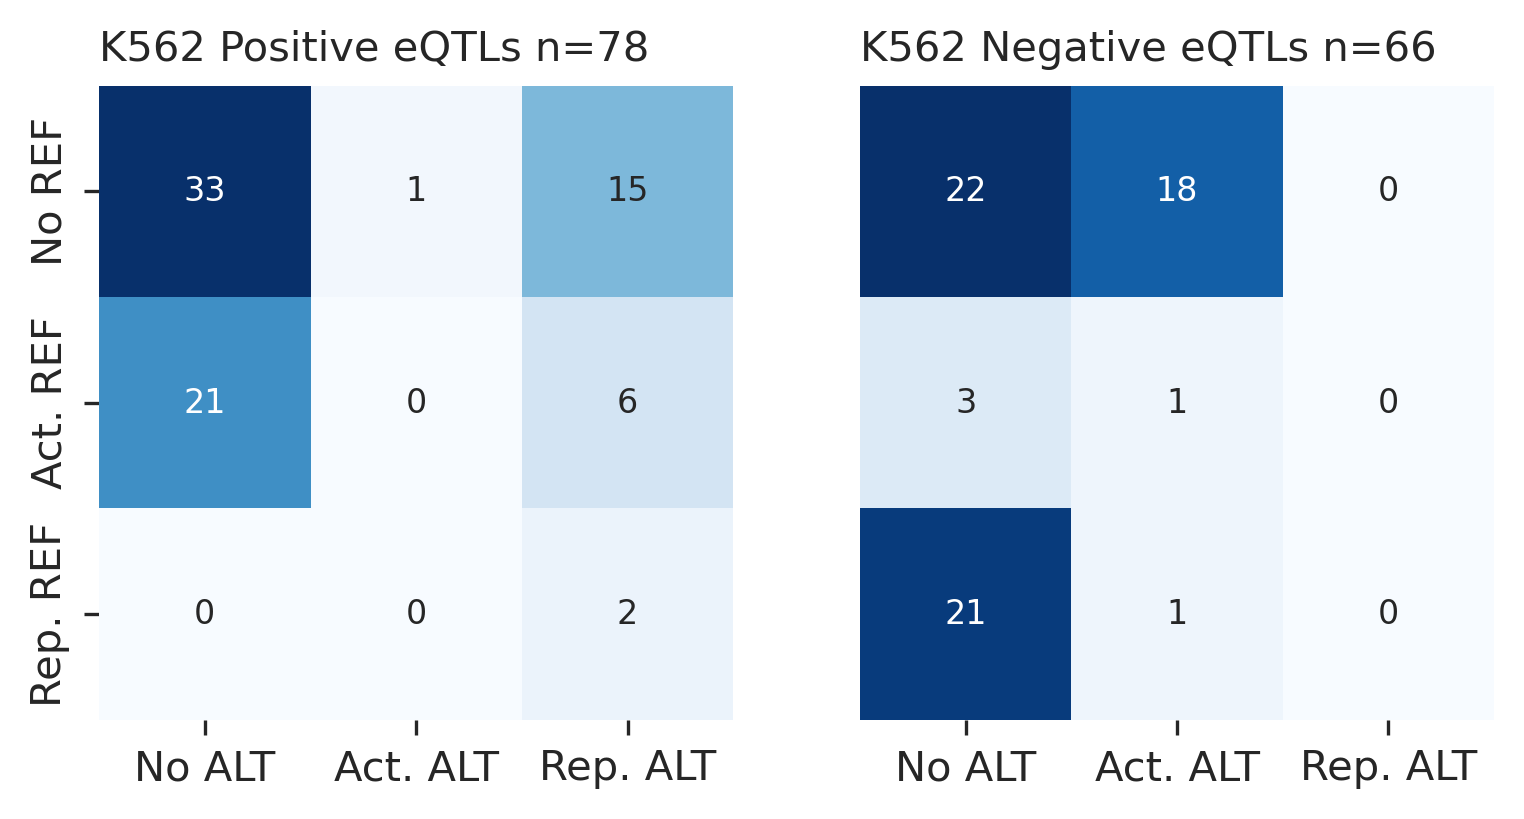

In [31]:
# plot 3x3s for all k562 emVars
k562_emVar_dict = plotTheFlank(
    k562_seqlets,
    k562_emVarAnnot,
    cCRE_start_dict,
    'K562',
    0,
    'Blues'
)

100%|██████████| 75/75 [00:00<00:00, 351.23it/s]

HEPG2
positive eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,31,63,1,0,16,3,0,0,7


negative eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,37,1,13,73,0,2,1,11,0


HEPG2
positive eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,19,2,8,15,0,1,0,5,0


negative eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,10,21,0,1,5,0,0,1,1


HEPG2 Concordant | 0bp pad


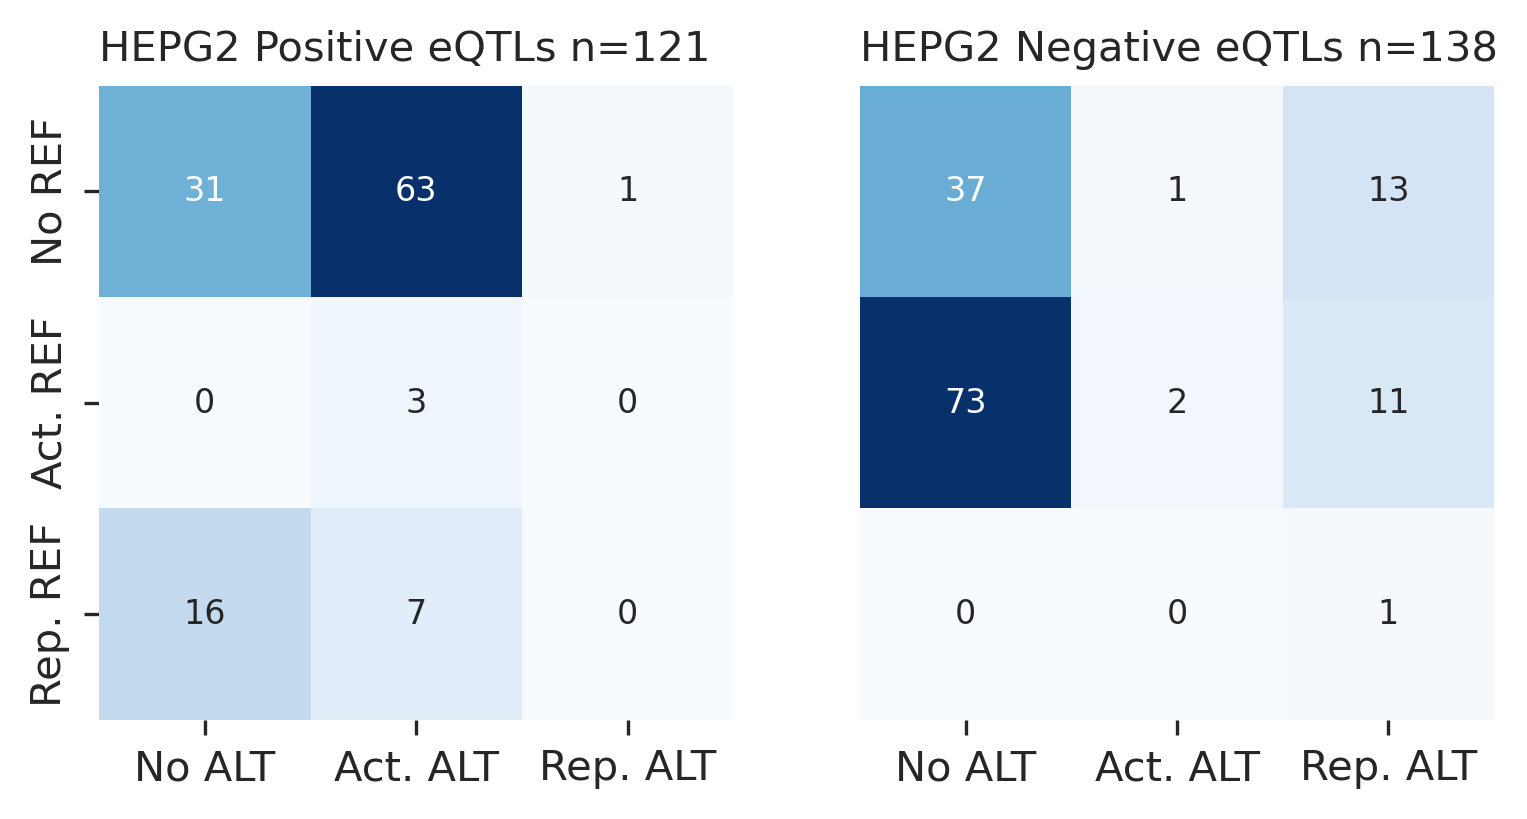

HEPG2 Discordant | 0bp pad


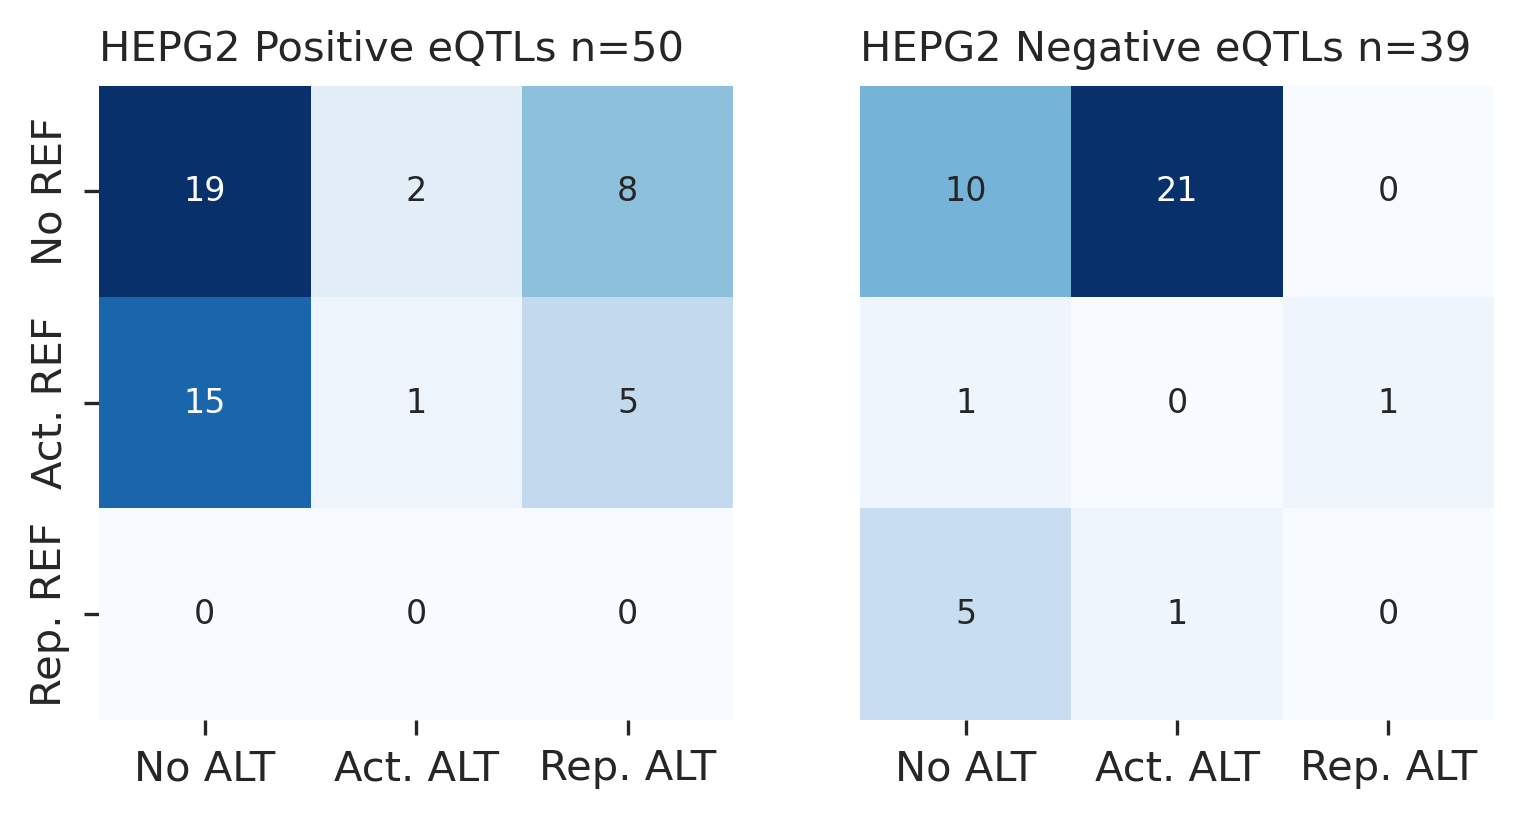

In [32]:
# plot 3x3s for all hepg2 emVars
hepg2_emVar_dict = plotTheFlank(
    hepg2_seqlets,
    hepg2_emVarAnnot,
    cCRE_start_dict,
    'HepG2',
    0,
    'Blues'
)

100%|██████████| 85/85 [00:00<00:00, 406.82it/s]

SKNSH
positive eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,47,60,2,0,15,5,0,0,6


negative eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,60,1,32,74,2,3,1,11,0


SKNSH
positive eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,19,2,11,17,0,0,1,2,0


negative eQTL


,no_seqlet_overlap,gain_activator,gain_repressor,lose_activator,lose_repressor,strengthen_act,strengthen_rep,flip_act_to_rep,flip_rep_to_act
0,23,16,0,1,14,0,0,0,2


SKNSH Concordant | 0bp pad


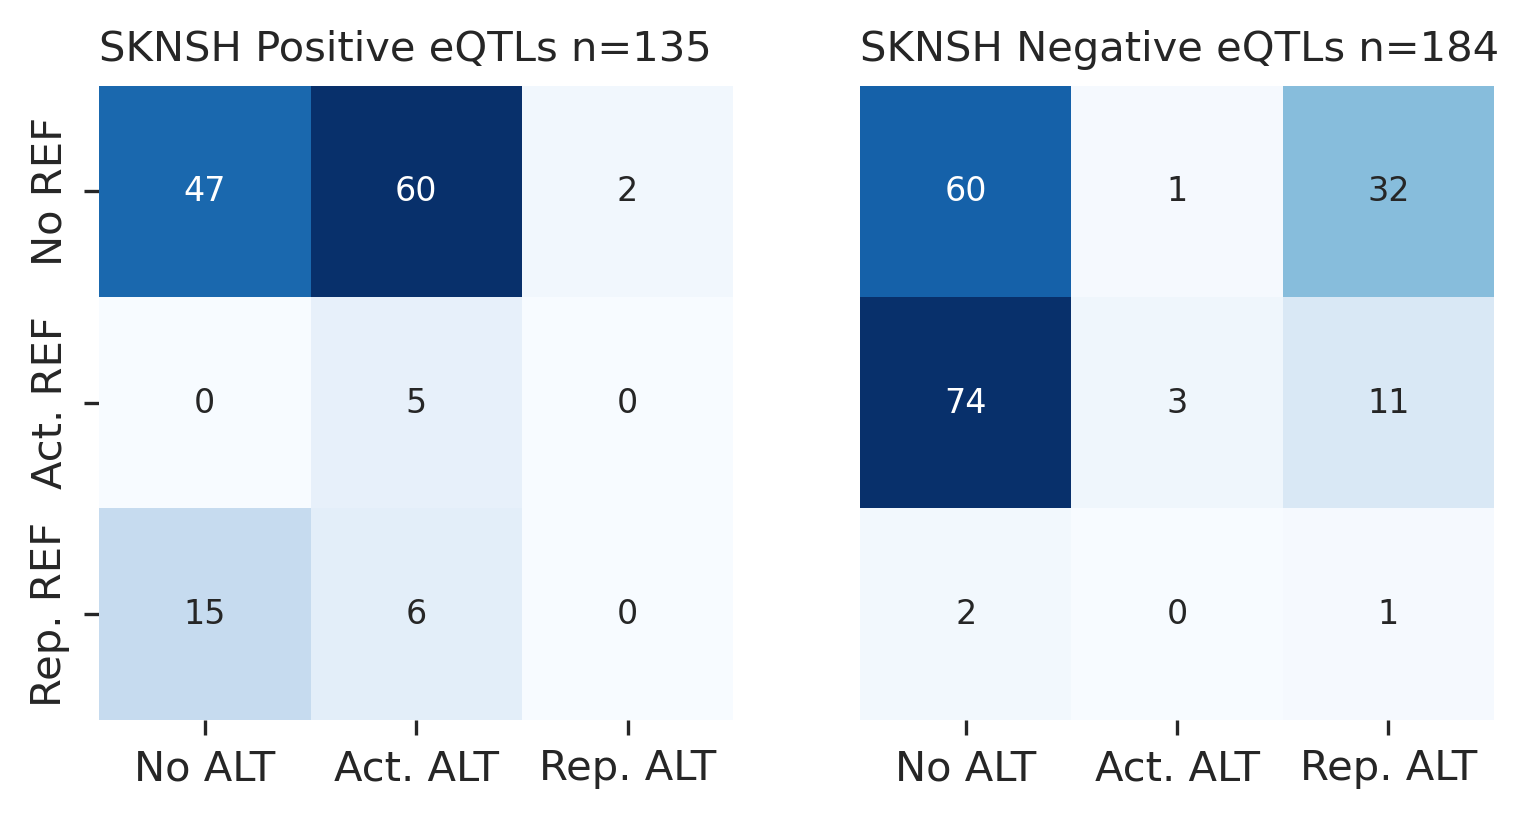

SKNSH Discordant | 0bp pad


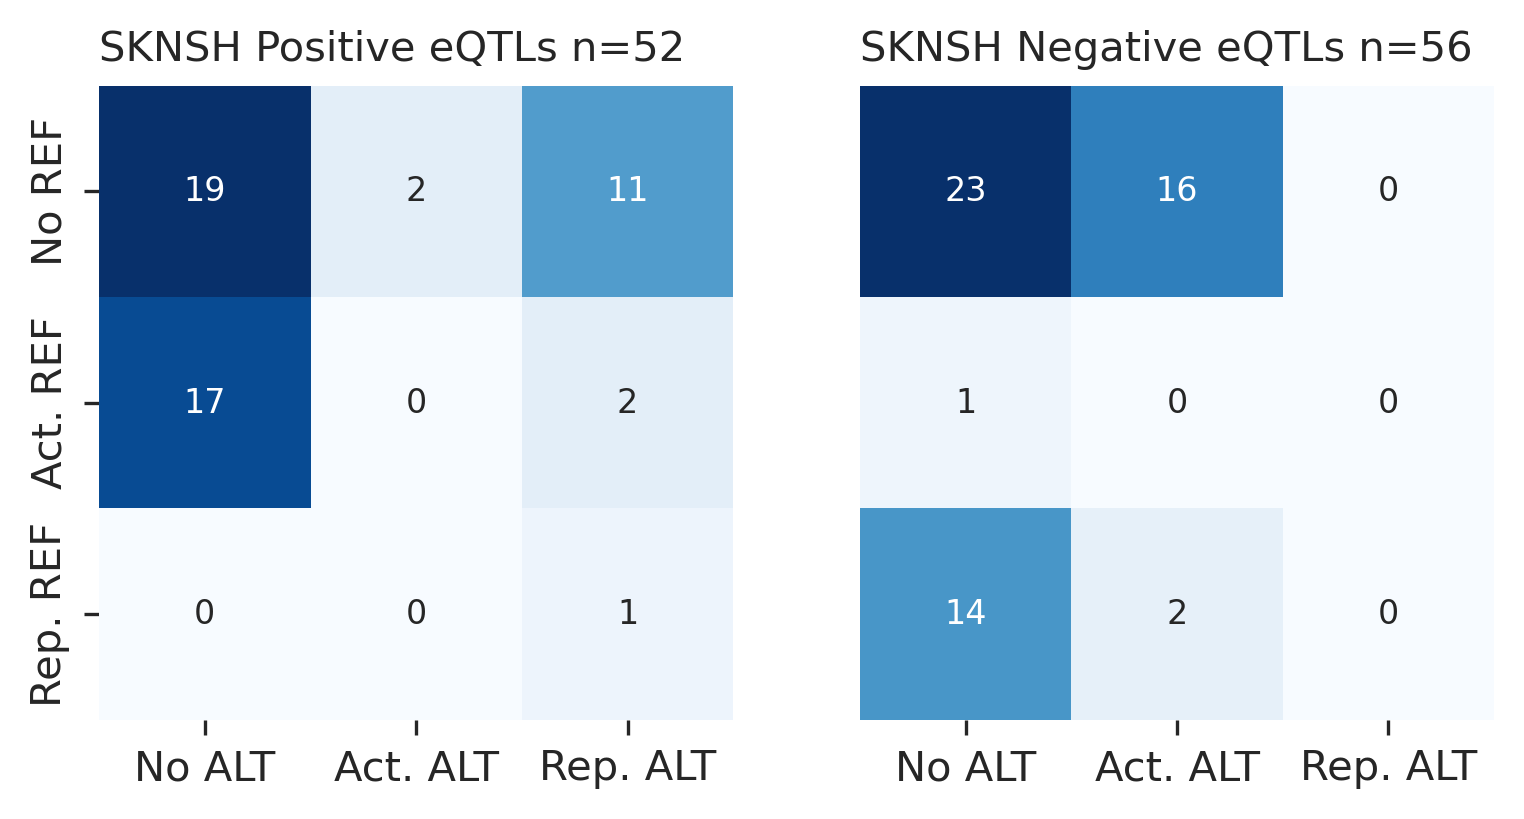

In [33]:
# plot 3x3s for all sknsh emVars
sknsh_emVar_dict = plotTheFlank(
    sknsh_seqlets,
    sknsh_emVarAnnot,
    cCRE_start_dict,
    'SKNSH',
    0,
    'Blues'
)

In [34]:
# plot the heatmaps all together
# make some custom colormaps
kColorMap = LinearSegmentedColormap.from_list('kCmap', ['oldlace', '#01A79D', '#01645e'])
hColorMap = LinearSegmentedColormap.from_list('kCmap', ['oldlace', '#FBB042', '#ba7004'])
sColorMap = LinearSegmentedColormap.from_list('kCmap', ['oldlace', '#EC2227', '#950d10'])

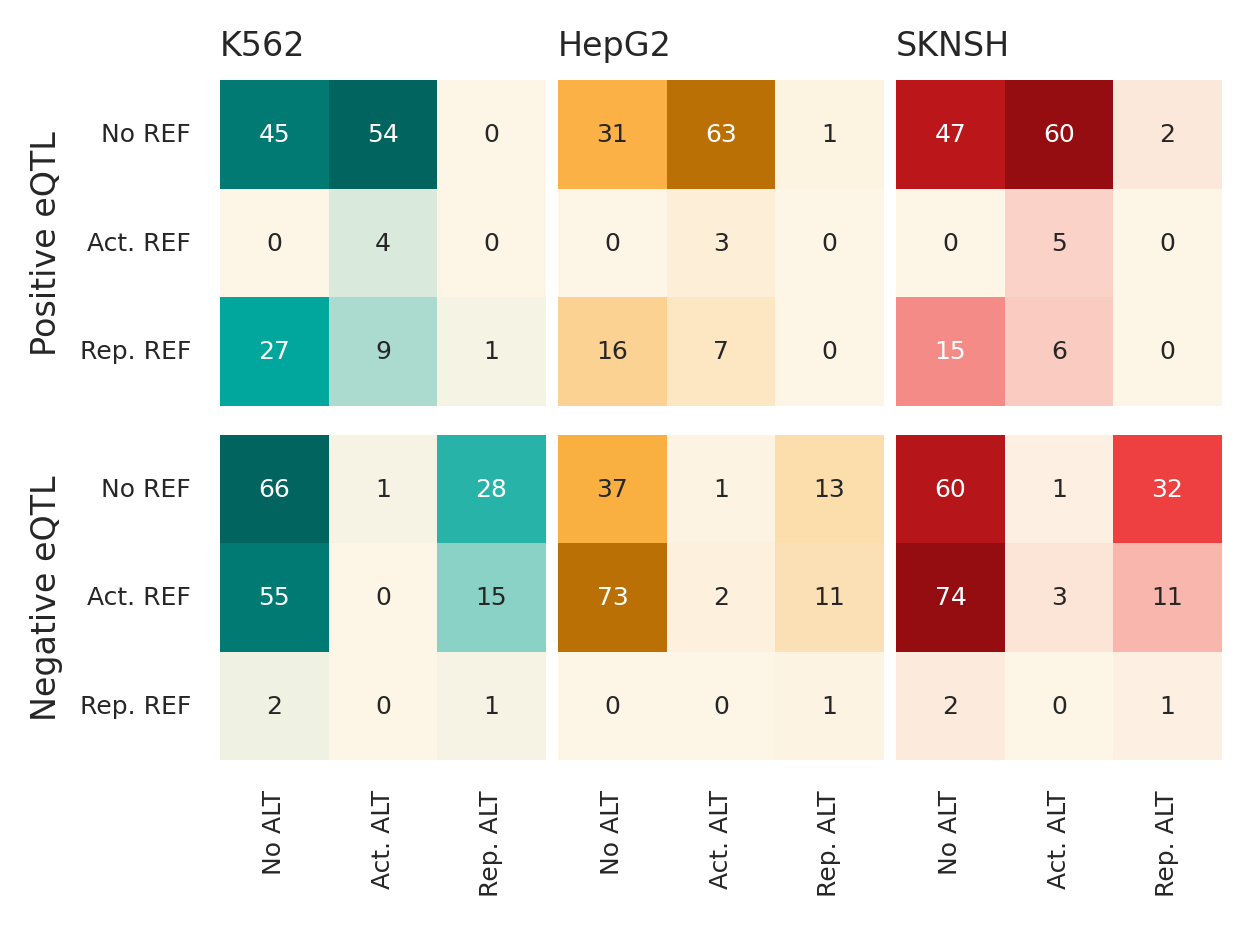

In [35]:
# plot all concordant matrices together
f = plt.figure(figsize=(4,3),dpi=300)
gs = f.add_gridspec(2, 3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
### plot activities in column 1 ###
# k562 positive eQTL #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set(adjustable='box', aspect='equal')
    sns.heatmap(
            k562_emVar_dict['concordant_posMatrix'],
            cmap=kColorMap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 6},
            cbar=False
        )
    plt.title(f'K562', fontsize = 8, loc='left')
    ax_01.set_xticks([], [], fontsize = 6, rotation = 90)
    ax_01.set_yticks([0.5,1.5,2.5], ['No REF', 'Act. REF', 'Rep. REF'], fontsize = 6, rotation = 0)
    ax_01.set_ylabel('Positive eQTL', fontsize = 8)
# k562 negative eQTL
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[1,0])
    ax_02.set(adjustable='box', aspect='equal')
    sns.heatmap(
            k562_emVar_dict['concordant_negMatrix'],
            cmap=kColorMap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 6},
            cbar=False
        )
    #plt.title(f'K562', fontsize = 8, loc='left')
    ax_02.set_xticks([0.5,1.5,2.5], ['No ALT', 'Act. ALT', 'Rep. ALT'], fontsize = 6, rotation = 90)
    ax_02.set_yticks([0.5,1.5,2.5], ['No REF', 'Act. REF', 'Rep. REF'], fontsize = 6, rotation = 0)
    ax_02.set_ylabel('Negative eQTL', fontsize = 8)
# hepg2 positive eQTL #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,1])
    ax_03.set(adjustable='box', aspect='equal')
    sns.heatmap(
            hepg2_emVar_dict['concordant_posMatrix'],
            cmap=hColorMap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 6},
            cbar=False
        )
    ax_03.set_xticks([], [], fontsize = 6, rotation = 90)
    ax_03.set_yticks([], [], fontsize = 6, rotation = 0)
    plt.title(f'HepG2', fontsize = 8, loc='left')
# hepg2 negative eQTL #
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[1,1])
    ax_04.set(adjustable='box', aspect='equal')
    sns.heatmap(
            hepg2_emVar_dict['concordant_negMatrix'],
            cmap=hColorMap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 6},
            cbar=False
        )
    ax_04.set_xticks([0.5,1.5,2.5], ['No ALT', 'Act. ALT', 'Rep. ALT'], fontsize = 6, rotation = 90)
    ax_04.set_yticks([], [], fontsize = 6, rotation = 0)
# sknsh positive eQTL #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,2])
    ax_05.set(adjustable='box', aspect='equal')
    sns.heatmap(
            sknsh_emVar_dict['concordant_posMatrix'],
            cmap=sColorMap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 6},
            cbar=False
        )
    ax_05.set_xticks([], [], fontsize = 6, rotation = 90)
    ax_05.set_yticks([], [], fontsize = 6, rotation = 0)
    plt.title(f'SKNSH', fontsize = 8, loc='left')
# sknsh negative eQTL #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[1,2])
    ax_06.set(adjustable='box', aspect='equal')
    sns.heatmap(
            sknsh_emVar_dict['concordant_negMatrix'],
            cmap=sColorMap,
            fmt = 'd',
            annot=True,
            annot_kws = {'size' : 6},
            cbar=False
        )
    ax_06.set_xticks([0.5,1.5,2.5], ['No ALT', 'Act. ALT', 'Rep. ALT'], fontsize = 6, rotation = 90)
    ax_06.set_yticks([], [], fontsize = 6, rotation = 0)
f.tight_layout(pad=0.1, w_pad=0.3, h_pad=0.1)
plt.savefig('gtex_mechanism_3x3_cell_matched_emVars_ref_Y.pdf', dpi=300)

In [36]:
# define a function to calculate the percent/number/etc of eQTLs explained by seqlets
def seqletOverlapSummary (matrixConcPos, 
                          matrixConcNeg,
                          cell_type):
    # calculate the percentage of emVars with seqlet overlap
    
    # negative
    # get total 
    allNeg = matrixConcNeg.sum().sum()
    # get the number of misses
    nMissNeg = matrixConcNeg[0].tolist()[0]
    # get the number with a seqlet overlap
    nNegSeqlet = (allNeg - nMissNeg)
    # calculate the percent with any overlap
    percentOverlapNeg =  nNegSeqlet / allNeg
    # get counts of concordant mechanisms
    loseAct = matrixConcNeg[0].tolist()[1]
    gainRep = matrixConcNeg[2].tolist()[0]
    flipActRep = matrixConcNeg[2].tolist()[1]
    strengthenRep = matrixConcNeg[2].tolist()[-1]
    # sum those
    concNegMechs = sum([
        loseAct,
        gainRep,
        flipActRep,
        strengthenRep,
    ])
    # calculate percentage of all calls that are concordant
    percentNegConc = concNegMechs / nNegSeqlet
    # calculate the gains of repressors
    NegGainRepPercent = gainRep / nNegSeqlet
    # calculate the loss of activators
    NegLoseActPercent = loseAct / nNegSeqlet
    
    # positive
    # get total
    allPos = matrixConcPos.sum().sum()
    # get the number of misses
    nMissPos = matrixConcPos[0].tolist()[0]
    # get the number with a seqlet overlap
    nPosSeqlet = (allPos - nMissPos)
    # calculate the percent with any overlap
    percentOverlapPos =  nPosSeqlet / allPos
    # get counts of concordant mechanisms
    gainAct = matrixConcPos[1].tolist()[0]
    loseRep = matrixConcPos[0].tolist()[-1]
    flipRepAct = matrixConcPos[1].tolist()[-1]
    strengthenAct = matrixConcPos[1].tolist()[1]
    # sum those
    concPosMechs = sum([
        gainAct,
        loseRep,
        flipRepAct,
        strengthenAct
    ])
    # calculate the percentage of all calls concordant calls
    percentagePosConc = concPosMechs / nPosSeqlet
    # calculate the loss of repressors
    PosLoseRepPercent = loseRep / nPosSeqlet
    # calculat the gain of activators
    PosGainActPercent = gainAct / nPosSeqlet

    # calculate total (pos and negative together)
    totalOverlapPercent = (nNegSeqlet + nPosSeqlet) / (allNeg + allPos)
    # calculate how many of those are concordant
    totalConcMechs = (concNegMechs + concPosMechs) / (nNegSeqlet + nPosSeqlet)

    # print the summary
    print(f'### {cell_type.upper()} ###')
    # total #
    print('Total:')
    print(f'{round(totalOverlapPercent,2)} percent of {cell_type.upper()} emVar-eQTLs have seqlets overlapping the variant')
    print(f'{round(totalConcMechs,2)} percent of {cell_type.upper()} seqlet mechanisms are consistent with eQTL direction')
    # negative #
    print('Negative eQTL:')
    print(f'{round(NegGainRepPercent, 2)} percent of seqlets overlapping negative eQTLs that result in gains of a repressor')
    print(f'{round(NegLoseActPercent, 2)} percent of seqlets overlapping negative eQTLs that result in the loss of an activator')
    # positive #
    print('Positive eQTL:')
    print(f'{round(PosLoseRepPercent, 2)} percent of seqlets overlapping positive eQTLs that result in the lose of a repressor')
    print(f'{round(PosGainActPercent, 2)} percent of seqlets overlapping positive eQTLs result in the gain of an activator')


In [37]:
seqletOverlapSummary(
    k562_emVar_dict['concordant_posMatrix'],
    k562_emVar_dict['concordant_negMatrix'],
    'k562'
)

### K562 ###
Total:
0.64 percent of K562 emVar-eQTLs have seqlets overlapping the variant
0.98 percent of K562 seqlet mechanisms are consistent with eQTL direction
Negative eQTL:
0.27 percent of seqlets overlapping negative eQTLs that result in gains of a repressor
0.54 percent of seqlets overlapping negative eQTLs that result in the loss of an activator
Positive eQTL:
0.28 percent of seqlets overlapping positive eQTLs that result in the lose of a repressor
0.57 percent of seqlets overlapping positive eQTLs result in the gain of an activator


In [38]:
seqletOverlapSummary(
    hepg2_emVar_dict['concordant_posMatrix'],
    hepg2_emVar_dict['concordant_negMatrix'],
    'hepg2'
)

### HEPG2 ###
Total:
0.74 percent of HEPG2 emVar-eQTLs have seqlets overlapping the variant
0.98 percent of HEPG2 seqlet mechanisms are consistent with eQTL direction
Negative eQTL:
0.13 percent of seqlets overlapping negative eQTLs that result in gains of a repressor
0.72 percent of seqlets overlapping negative eQTLs that result in the loss of an activator
Positive eQTL:
0.18 percent of seqlets overlapping positive eQTLs that result in the lose of a repressor
0.7 percent of seqlets overlapping positive eQTLs result in the gain of an activator


In [39]:
seqletOverlapSummary(
    sknsh_emVar_dict['concordant_posMatrix'],
    sknsh_emVar_dict['concordant_negMatrix'],
    'sknsh'
)

### SKNSH ###
Total:
0.66 percent of SKNSH emVar-eQTLs have seqlets overlapping the variant
0.96 percent of SKNSH seqlet mechanisms are consistent with eQTL direction
Negative eQTL:
0.26 percent of seqlets overlapping negative eQTLs that result in gains of a repressor
0.6 percent of seqlets overlapping negative eQTLs that result in the loss of an activator
Positive eQTL:
0.17 percent of seqlets overlapping positive eQTLs that result in the lose of a repressor
0.68 percent of seqlets overlapping positive eQTLs result in the gain of an activator


In [40]:
# define a palette for coloring titles by eQTL mechanism
paired_palette = [
    '#1F78B4',  # dark blue
    '#33A02C',  # dark green
    '#E31A1C',  # dark red
    '#FF7F00',  # dark orange
    '#6A3D9A',  # dark purple (from Paired)
    '#B15928',  # dark brown (from Paired)
    '#1B9E77',  # dark teal (from Dark2)
    '#E7298A',  # dark pink (from Dark2)
    '#666666',  # dark gray (from Dark2)
]
mechs = list(pd.Series(k562_emVar_dict['concordant_mech_dict'].values()).unique())

eQTL_mechanism_palette = dict(zip(
    mechs,
    paired_palette
))

In [48]:
### let's move into the contribution portion of the show ###
# plot ref and alt for each variant by category

In [41]:
"""
Updated plotting pipeline with optional saturation mutagenesis lollipop panels.

Changes vs. the original:
    1. New helper `plotLollipop` — draws the sat mut skew lollipop chart.
    2. `plotHelp` — UNCHANGED (re-included here for completeness).
    3. `plotRefAlt` — accepts optional `ref_satmut`, `alt_satmut`, `include_lollipop`.
       When lollipops are requested, builds a 4-panel figure
       (REF logo / REF lollipop / ALT logo / ALT lollipop) with shared x-axis.
    4. `dict4plot` — accepts an optional `satmutTensors` dict (same nesting as
       `plotLogoTensors`) and stores the per-pair sat mut tensors in the output.
    5. `plot_specific_enhancers` — accepts `include_lollipop` flag, passes it through.

Padding note:
    The contribution tensors are zero-padded to length 350 on the right.
    `plotHelp` strips those zero rows internally, so the logo's x-axis
    runs 0 .. L-1 where L is the actual enhancer length. The sat mut
    tensor is already (4, L) with no padding, so it aligns 1:1 with the
    stripped contribution tensor on the same x-axis. As long as both
    tensors are derived from the same enhancer sequence, no extra
    alignment work is needed.
"""

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import logomaker
from tqdm import tqdm


# ------------------------------------------------------------------ #
# Module-level rcParams for Illustrator-editable PDF + Helvetica
# ------------------------------------------------------------------ #
# fonttype 42 = TrueType embedding (text stays editable in Illustrator).
# fonttype 3 (the matplotlib default) converts text to paths, which
# Illustrator can still edit as shapes but not as text.
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'   # text stays as text in SVG too

# Helvetica with sensible fallbacks if it isn't installed on the system.
# Matplotlib walks this list and uses the first one it can find.
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica', 'Arial',
                                           'Liberation Sans', 'DejaVu Sans']

# White figure background (avoids surprises when Illustrator opens the PDF
# on a colored artboard).
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'

# Note on logomaker:
#   The A/C/G/T letters in the logo panels are drawn as filled vector PATHS
#   by logomaker, not as matplotlib text. So in Illustrator they appear as
#   editable shapes (recolor, transform, etc.) but NOT as text you can retype.
#   This is a logomaker rendering choice; no rcParam will change it.
#   Everything else (TF labels, tick labels, suptitle, REF/ALT/skew labels)
#   is live, editable Helvetica text.


# ------------------------------------------------------------------ #
# 0. NEW: helpers for plot_range slicing
# ------------------------------------------------------------------ #
def _unpadded_length(tensor):
    """Length of the (4, L) tensor up to the last non-zero column.

    Contribution tensors are right-padded with zeros to 350; this finds
    where the real sequence ends so we can match it to the un-padded
    sat mut tensor before slicing.
    """
    col_abs_sums = tensor.abs().sum(dim=0)
    nonzero = (col_abs_sums > 0).nonzero(as_tuple=True)[0]
    if len(nonzero) == 0:
        return 0
    return int(nonzero.max().item()) + 1


def _clip_bed_to_range(bed, slice_start_bed, slice_stop_bed):
    """Filter seqlets that overlap the slice, then clip their start/stop
    to the slice boundaries so they don't extend past the visible window.

    Parameters
    ----------
    bed : DataFrame; col 1 is BED start (incl, 0-based), col 2 is BED stop (excl, 0-based)
    slice_start_bed : int, 0-based inclusive genomic start of the slice
    slice_stop_bed  : int, 0-based exclusive genomic stop of the slice
    """
    if len(bed) == 0:
        return bed.copy()
    starts = bed.iloc[:, 1]
    stops = bed.iloc[:, 2]
    # overlap: BED [s, e) intersects [slice_start, slice_stop)
    overlap_mask = (starts < slice_stop_bed) & (stops > slice_start_bed)
    out = bed.loc[overlap_mask].copy()
    if len(out) == 0:
        return out
    out.iloc[:, 1] = out.iloc[:, 1].clip(lower=slice_start_bed)
    out.iloc[:, 2] = out.iloc[:, 2].clip(upper=slice_stop_bed)
    return out


# ------------------------------------------------------------------ #
# 1. NEW: lollipop helper
# ------------------------------------------------------------------ #
def plotLollipop(satmut_tensor,
                 enhBED,
                 enhStart,
                 LeadVar,
                 ax,
                 ylim=None,
                 show_xaxis=True,
                 compact=False):
    """
    Plot a saturation-mutagenesis lollipop panel.

    Parameters
    ----------
    satmut_tensor : torch.Tensor of shape (4, L)
        Rows are A, C, G, T. L is the actual enhancer length (NOT padded
        to 350). At each position, the reference base has skew = 0 and
        the three alternative bases carry the predicted skew values.
    enhBED : DataFrame
        Same seqlet bed used by plotHelp (for matching grey shaded blocks).
    enhStart : int
        Genomic start coordinate of position 0 of the (un-padded) sequence.
    LeadVar : int
        Genomic position of the lead variant.
    ax : matplotlib Axes
        Axis to draw onto.
    ylim : tuple (lo, hi) or None
        Shared y-range. If None, uses tensor min/max with 10% pad.
    show_xaxis : bool
        Whether to draw genomic-coordinate tick labels on this axis.
    """
    # (L, 4) DataFrame indexed 0 .. L-1
    df = pd.DataFrame(satmut_tensor.numpy()).T
    df.columns = ['A', 'C', 'G', 'T']
    seq_length = len(df)

    # Logomaker default ACGT colors
    base_colors = {
        'A': '#008000',  # green
        'C': '#0000CC',  # blue
        'G': '#FFB300',  # orange/gold
        'T': '#CC0000',  # red
    }

    # Y-limits: prefer caller's, otherwise symmetric around zero
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        abs_max = float(np.abs(df.values).max())
        ax.set_ylim(-abs_max * 1.10, abs_max * 1.10)

    # Background: seqlet shading (faint, so the lollipops still pop)
    for _, row in enhBED.iterrows():
        start, stop = row[[1, 2]].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        ax.axvspan(start - 0.5, stop + 0.5,
                   color='gainsboro', alpha=0.35, zorder=0,
                   linewidth=0)

    # Lead variant red shade (matches plotHelp) — only if it falls in view
    LeadVarPos = int(LeadVar - enhStart - 1)
    if 0 <= LeadVarPos < seq_length:
        ax.axvspan(LeadVarPos - 0.5, LeadVarPos + 0.5,
                   color='red', alpha=0.35, zorder=0, linewidth=0)

    # Zero baseline
    ax.axhline(0, color='black', linewidth=0.5, zorder=1)

    # Compact-mode sizing
    stem_lw = 0.30 if compact else 0.60
    dot_s = 2.5 if compact else 6
    tick_label_fs = 5 if compact else None
    y_tick_label_fs = 5 if compact else None
    tick_len_major = 2.5 if compact else 5
    tick_len_minor = 1.5 if compact else 2.5
    tick_pad = 2 if compact else 5

    # Stems + dots, per base — all bases at the same integer x; dots
    # separate naturally on the y-axis by their skew values
    for base in ['A', 'C', 'G', 'T']:
        x = np.arange(seq_length)
        y = df[base].values
        # filter exact zeros (these are the reference base at each pos)
        mask = np.abs(y) > 1e-9
        if not mask.any():
            continue
        ax.vlines(x[mask], 0, y[mask],
                  color=base_colors[base],
                  alpha=0.55, linewidth=stem_lw, zorder=2)
        ax.scatter(x[mask], y[mask],
                   color=base_colors[base],
                   s=dot_s, alpha=0.9,
                   edgecolors='none', zorder=3)

    # Match logo x-extent
    ax.set_xlim(-0.5, seq_length - 0.5)

    # Spines: keep only the left so the y-axis numbers are readable
    for side in ('top', 'right', 'bottom'):
        ax.spines[side].set_visible(False)

    # Genomic coordinate ticks (mirror plotHelp's logic exactly)
    first_minor_genomic = ((enhStart // 10) + 1) * 10
    major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []
    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticks(minor_tick_positions, minor=True)
    if show_xaxis:
        if tick_label_fs is not None:
            ax.set_xticklabels(major_tick_labels, rotation=45, ha='right',
                               rotation_mode='anchor', fontsize=tick_label_fs)
        else:
            ax.set_xticklabels(major_tick_labels,
                               rotation=45, ha='right', rotation_mode='anchor')
    else:
        ax.set_xticklabels([])
    ax.tick_params(axis='x', which='major', length=tick_len_major, pad=tick_pad)
    ax.tick_params(axis='x', which='minor', length=tick_len_minor)
    if y_tick_label_fs is not None:
        ax.tick_params(axis='y', labelsize=y_tick_label_fs)


# ------------------------------------------------------------------ #
# 2. plotHelp — UNCHANGED, included for completeness
# ------------------------------------------------------------------ #
def plotHelp(tensors2plot,
             enhBED,
             enhStart,
             LeadVar,
             ax=None,
             ylim=None,
             show_xaxis=True,
             skip_padding_filter=False,
             compact=False):
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy()
    renamedDF = dfFromTensor.rename(columns={0: 'A', 1: 'C', 2: 'G', 3: 'T'})
    if not skip_padding_filter:
        renamedDF = renamedDF.loc[renamedDF.sum(axis=1) != 0]
        enhStart = enhStart + renamedDF.index[0]
        renamedDF = renamedDF.reset_index(drop=True)
    seq_length = len(renamedDF)

    data_min = renamedDF.clip(upper=0).sum(axis=1).min()
    data_max = renamedDF.clip(lower=0).sum(axis=1).max()
    data_min = min(data_min, 0) * 1.05
    data_max = max(data_max, 0) * 1.05

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=[20, 2.5])
        created_fig = True

    logoCheck = logomaker.Logo(renamedDF, ax=ax)

    if ylim is not None:
        logoCheck.ax.set_ylim(*ylim)
    else:
        logoCheck.ax.set_ylim(data_min, data_max)

    # Compact-mode sizing
    tf_label_fs = 5 if compact else 8
    tf_half_width_factor = 1.5 if compact else 2.5  # collision heuristic
    top_y_step = 0.04 if compact else 0.05
    bot_y_step = 0.10 if compact else 0.12
    tick_label_fs = 5 if compact else None
    y_tick_label_fs = 5 if compact else None
    tick_len_major = 2.5 if compact else 5
    tick_len_minor = 1.5 if compact else 2.5
    tick_pad = 2 if compact else 5

    top_annotations = []
    bottom_annotations = []
    min_spacing = 3

    def get_annotation_level(x_center, text_half_width, existing_annotations):
        level = 0
        while True:
            conflict = False
            for other_center, other_half_width, other_level in existing_annotations:
                if other_level == level:
                    distance = abs(x_center - other_center)
                    min_dist = text_half_width + other_half_width + min_spacing
                    if distance < min_dist:
                        conflict = True
                        break
            if not conflict:
                return level
            level += 1

    for _, row in enhBED.iterrows():
        start, stop, actClass, tf = row[[1, 2, 'tf_class', 'tf']].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        x_center = (stop + start) / 2
        x_center_norm = x_center / seq_length
        tf_label = tf.split('_')[0]
        text_half_width = len(tf_label) * tf_half_width_factor

        if actClass == 'activator':
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5,
                                               color='gainsboro', edgecolor='k', floor=0)
            level = get_annotation_level(x_center, text_half_width, top_annotations)
            top_annotations.append((x_center, text_half_width, level))
            y_offset = 1.05 + level * top_y_step
            ax.annotate(tf_label,
                        xy=(x_center_norm, 1.0), xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset), textcoords='axes fraction',
                        fontsize=tf_label_fs, fontstyle='italic',
                        ha='center', va='bottom', annotation_clip=False)
        else:
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5,
                                               color='gainsboro', edgecolor='k', ceiling=0)
            level = get_annotation_level(x_center, text_half_width, bottom_annotations)
            bottom_annotations.append((x_center, text_half_width, level))
            y_offset = -0.01 - level * bot_y_step
            ax.annotate(tf_label,
                        xy=(x_center_norm, 0.0), xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset), textcoords='axes fraction',
                        fontsize=tf_label_fs, fontstyle='italic',
                        ha='center', va='top', annotation_clip=False)

    LeadVarPos = int(LeadVar - enhStart - 1)
    if 0 <= LeadVarPos < seq_length:
        lead_contribution = renamedDF.iloc[LeadVarPos].sum()
        if lead_contribution >= 0:
            logoCheck.highlight_position(p=LeadVarPos, color='red', alpha=0.5, floor=0)
        else:
            logoCheck.highlight_position(p=LeadVarPos, color='red', alpha=0.5, ceiling=0)

    logoCheck.style_spines(visible=False)

    first_minor_genomic = ((enhStart // 10) + 1) * 10
    major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []
    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticks(minor_tick_positions, minor=True)
    if show_xaxis:
        if tick_label_fs is not None:
            ax.set_xticklabels(major_tick_labels, rotation=45, ha='right',
                               rotation_mode='anchor', fontsize=tick_label_fs)
        else:
            ax.set_xticklabels(major_tick_labels, rotation=45, ha='right',
                               rotation_mode='anchor')
    else:
        ax.set_xticklabels([])
    ax.tick_params(axis='x', which='major', length=tick_len_major, pad=tick_pad)
    ax.tick_params(axis='x', which='minor', length=tick_len_minor)
    if y_tick_label_fs is not None:
        ax.tick_params(axis='y', labelsize=y_tick_label_fs)

    result = {
        'data_min': data_min,
        'data_max': data_max,
        'top_level_max': max([lvl for _, _, lvl in top_annotations], default=-1),
        'bottom_level_max': max([lvl for _, _, lvl in bottom_annotations], default=-1),
    }

    if created_fig:
        plt.tight_layout()
        plt.show()
        plt.close()

    return result


# ------------------------------------------------------------------ #
# 3. UPDATED: plotRefAlt with optional lollipop panels
# ------------------------------------------------------------------ #
def plotRefAlt(ref_tensor, alt_tensor,
               ref_bed, alt_bed,
               enhStart, LeadVar,
               titleColor,
               mechanism,
               cell_type,
               enh_var,
               variantDir,
               concordance,
               title=None,
               ref_satmut=None,
               alt_satmut=None,
               include_lollipop=False,
               plot_range=None,
               compact=False,
               figsize=None,
               output_format='png'):
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300

    # ---------- optional sub-range slicing ---------- #
    # plot_range is a tuple (start_gen, end_gen) of inclusive 1-based
    # genomic coordinates matching what plotHelp displays on the x-axis.
    sliced = plot_range is not None
    if sliced:
        start_gen, end_gen = plot_range
        # Strip right padding from the contribution tensors so both they
        # and the (un-padded) sat mut tensors share a common base length.
        ref_L = _unpadded_length(ref_tensor)
        alt_L = _unpadded_length(alt_tensor)
        L = max(ref_L, alt_L)
        ref_tensor = ref_tensor[:, :L]
        alt_tensor = alt_tensor[:, :L]

        # Convert genomic coords → tensor indices (mirrors plotHelp's -1
        # offset for the displayed 1-based positions).
        i_start = start_gen - enhStart - 1
        i_end = end_gen - enhStart - 1
        i_start_c = max(0, i_start)
        i_end_c = min(L - 1, i_end)
        if i_start_c > i_end_c:
            raise ValueError(
                f"plot_range {plot_range} falls outside the enhancer "
                f"(genomic {enhStart + 1}..{enhStart + L})"
            )

        # Slice all four tensors
        ref_tensor = ref_tensor[:, i_start_c:i_end_c + 1]
        alt_tensor = alt_tensor[:, i_start_c:i_end_c + 1]
        if ref_satmut is not None:
            ref_satmut = ref_satmut[:, i_start_c:i_end_c + 1]
        if alt_satmut is not None:
            alt_satmut = alt_satmut[:, i_start_c:i_end_c + 1]

        # Filter + clip BEDs to the visible window (BED coords are 0-based)
        slice_start_bed = enhStart + i_start_c
        slice_stop_bed = enhStart + i_end_c + 1
        ref_bed = _clip_bed_to_range(ref_bed, slice_start_bed, slice_stop_bed)
        alt_bed = _clip_bed_to_range(alt_bed, slice_start_bed, slice_stop_bed)

        # New enhStart so the tick labels still read the original genomic coords
        enhStart = enhStart + i_start_c

    # ---------- shared y-range for the two LOGO panels ---------- #
    def _logo_range(t):
        df = pd.DataFrame(t.numpy()).T
        # only filter padding rows when we haven't already done the slicing
        if not sliced:
            df = df.loc[df.sum(axis=1) != 0]
        return (min(df.clip(upper=0).sum(axis=1).min(), 0),
                max(df.clip(lower=0).sum(axis=1).max(), 0))
    ref_lo, ref_hi = _logo_range(ref_tensor)
    alt_lo, alt_hi = _logo_range(alt_tensor)
    shared_ylim = (min(ref_lo, alt_lo) * 1.05, max(ref_hi, alt_hi) * 1.05)

    # Decide whether we actually have what we need for lollipops
    plot_lollipops = (include_lollipop
                      and ref_satmut is not None
                      and alt_satmut is not None)
    if include_lollipop and not plot_lollipops:
        print(f"[plotRefAlt] include_lollipop=True but sat-mut tensors missing "
              f"for {enh_var}; falling back to 2-panel layout.")

    # ---------- shared y-range for the two LOLLIPOP panels (symmetric) ---------- #
    if plot_lollipops:
        ref_abs_max = float(np.abs(ref_satmut.numpy()).max())
        alt_abs_max = float(np.abs(alt_satmut.numpy()).max())
        lol_abs = max(ref_abs_max, alt_abs_max)
        shared_lol_ylim = (-lol_abs * 1.10, lol_abs * 1.10)

    # ---------- figure layout ---------- #
    # Compact-mode defaults: ~4x3 in with lollipops, ~4x2 in without
    if figsize is None:
        if compact:
            figsize = [4, 3] if plot_lollipops else [4, 2]
        else:
            figsize = [20, 9] if plot_lollipops else [20, 5.5]

    # Compact font sizes
    ref_alt_label_fs = 6 if compact else 10
    skew_label_fs = 5 if compact else 8
    title_fs = 7 if compact else None  # None → matplotlib default
    hspace_lol = 0.30 if compact else 0.35
    hspace_no_lol = 0.50 if compact else 0.6
    adjust_top = 0.90 if compact else 0.85
    adjust_bottom = 0.12 if compact else 0.15

    if plot_lollipops:
        fig, axes = plt.subplots(
            nrows=4, ncols=1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={'hspace': hspace_lol,
                         'height_ratios': [3, 1.2, 3, 1.2]}
        )
        ax_ref_logo, ax_ref_lol, ax_alt_logo, ax_alt_lol = axes
    else:
        fig, (ax_ref_logo, ax_alt_logo) = plt.subplots(
            nrows=2, ncols=1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={'hspace': hspace_no_lol}
        )

    # ---------- REF panels ---------- #
    plotHelp(ref_tensor, ref_bed, enhStart, LeadVar,
             ax=ax_ref_logo, ylim=shared_ylim, show_xaxis=False,
             skip_padding_filter=sliced, compact=compact)
    ax_ref_logo.set_ylabel('REF', rotation=0, ha='right', va='center',
                           fontsize=ref_alt_label_fs)

    if plot_lollipops:
        plotLollipop(ref_satmut, ref_bed, enhStart, LeadVar,
                     ax=ax_ref_lol, ylim=shared_lol_ylim, show_xaxis=False,
                     compact=compact)
        ax_ref_lol.set_ylabel('REF\nskew', rotation=0, ha='right',
                              va='center', fontsize=skew_label_fs)

    # ---------- ALT panels ---------- #
    # If a lollipop will follow the ALT logo, suppress its x-axis;
    # the bottom-most lollipop carries the labels.
    show_alt_logo_x = not plot_lollipops
    plotHelp(alt_tensor, alt_bed, enhStart, LeadVar,
             ax=ax_alt_logo, ylim=shared_ylim, show_xaxis=show_alt_logo_x,
             skip_padding_filter=sliced, compact=compact)
    ax_alt_logo.set_ylabel('ALT', rotation=0, ha='right', va='center',
                           fontsize=ref_alt_label_fs)

    if plot_lollipops:
        plotLollipop(alt_satmut, alt_bed, enhStart, LeadVar,
                     ax=ax_alt_lol, ylim=shared_lol_ylim, show_xaxis=True,
                     compact=compact)
        ax_alt_lol.set_ylabel('ALT\nskew', rotation=0, ha='right',
                              va='center', fontsize=skew_label_fs)

    # ---------- title ---------- #
    if title:
        suptitle_kwargs = dict(y=0.98, color=titleColor, fontweight='bold')
        if title_fs is not None:
            suptitle_kwargs['fontsize'] = title_fs
        fig.suptitle(title, **suptitle_kwargs)

    plt.subplots_adjust(top=adjust_top, bottom=adjust_bottom)

    # ---------- save ---------- #
    suffix = '_lollipop' if plot_lollipops else ''
    if sliced:
        suffix += f'_zoom{plot_range[0]}_{plot_range[1]}'
    if compact:
        suffix += '_compact'
    outpath = (f'singlePlots/'
               f'{variantDir}_{mechanism}_{enh_var}_{cell_type}{suffix}.{output_format}')
    if compact:
        plt.savefig(outpath, dpi=300, bbox_inches='tight', pad_inches=0.05)
        #plt.show()
    else:
        plt.savefig(outpath, dpi=300)
        #plt.show()
    plt.show()
    plt.close()


# ------------------------------------------------------------------ #
# 4. UPDATED: dict4plot now optionally pulls sat mut tensors
# ------------------------------------------------------------------ #
def dict4plot(reformatted_var_info,
              leadVarBED,
              mechanismDict,
              plotLogoTensors,
              varDirDict,
              cCRE_start_dict,
              cell_type,
              satmutTensors=None):
    """
    `satmutTensors` is an optional nested dict with the same shape as
    `plotLogoTensors`:  {cell_type_key : {enh_var_id : tensor(4, L)}}
    where L is the un-padded enhancer length. If provided, per-pair
    sat mut tensors are looked up and stored in the output dict.
    """
    dict2return = {}
    cell_key = 'HepG2' if cell_type == 'hepg2' else cell_type.upper()

    for enh_var in tqdm(reformatted_var_info['enhancer_leadVar_pair']):
        enhID = enh_var.split('_')[0]
        enhStart = cCRE_start_dict.get(enhID)
        chrom = enh_var.split('_')[1]
        leadVar = '_'.join(enh_var.split('_')[1:])
        leadVarPos = int(leadVar.split('_')[1])
        leadVarDir = varDirDict.get(enh_var)
        leadVarMechanism = mechanismDict.get(enh_var)

        # alt background (the variant id itself)
        altBackground_seqlets = leadVarBED[leadVarBED['filter_id'] == enh_var].copy()
        altBackground_plotLogoTensors = plotLogoTensors[cell_key][enh_var]

        # ref background ("<enhID>_REF")
        enh_ref = f"{enh_var.split('_')[0]}_REF"
        refBackground_seqlets = leadVarBED[leadVarBED['filter_id'] == enh_ref].copy()
        refBackground_plotLogoTensors = plotLogoTensors[cell_key][enh_ref]

        # NEW: sat mut tensors (optional)
        ref_satmut = None
        alt_satmut = None
        if satmutTensors is not None:
            ref_satmut = satmutTensors.get(cell_key, {}).get(enh_ref)
            alt_satmut = satmutTensors.get(cell_key, {}).get(enh_var)

        dict2return[enh_var] = {
            'enhancer_id': enhID,
            'enhancer_start': enhStart,
            'chrom': chrom,
            'leadVariant': leadVar,
            'leadVariant_pos': leadVarPos,
            'leadVariant_dir': leadVarDir,
            'eQTL_mechanism': leadVarMechanism,
            'alt_background_bed': altBackground_seqlets,
            'ref_background_bed': refBackground_seqlets,
            'alt_background_plotLogoTensors': altBackground_plotLogoTensors,
            'ref_background_plotLogoTensors': refBackground_plotLogoTensors,
            'alt_background_satmut': alt_satmut,
            'ref_background_satmut': ref_satmut,
        }
    return dict2return


# ------------------------------------------------------------------ #
# 5. UPDATED: top-level iteration with include_lollipop flag
# ------------------------------------------------------------------ #
def plot_specific_enhancers(cell, annotation_dict, concordance,
                            include_lollipop=False):
    for enh_var in annotation_dict.keys():
        d = annotation_dict[enh_var]
        mechanism = d.get('eQTL_mechanism')
        varDir = d.get('leadVariant_dir')
        titleColor = eQTL_mechanism_palette.get(mechanism)  # noqa: F821
        plotRefAlt(
            ref_tensor=d['ref_background_plotLogoTensors'],
            alt_tensor=d['alt_background_plotLogoTensors'],
            ref_bed=d['ref_background_bed'],
            alt_bed=d['alt_background_bed'],
            enhStart=d['enhancer_start'],
            LeadVar=d['leadVariant_pos'],
            titleColor=titleColor,
            mechanism=mechanism,
            cell_type=cell,
            enh_var=enh_var,
            variantDir=varDir,
            concordance=concordance,
            ref_satmut=d.get('ref_background_satmut'),
            alt_satmut=d.get('alt_background_satmut'),
            include_lollipop=include_lollipop,
            title=(f" {cell.upper()} | {enh_var.split('_')[0]}  |  "
                   f"lead: {d.get('leadVariant')} | eQTL Dir: {varDir} | "
                   f"{mechanism}"),
        )


# ------------------------------------------------------------------ #
# 6. NEW: single-enhancer entry point with optional plot_range
# ------------------------------------------------------------------ #
def plot_single_enhancers(cell, annotation_dict, concordance, enh_var,
                          include_lollipop=False, plot_range=None,
                          compact=False, figsize=None, output_format='png'):
    """
    Plot a single enhancer/variant pair, optionally restricted to a
    genomic sub-window.

    Parameters
    ----------
    annotation_dict : dict
        The per-pair sub-dict (one value from `dict4plot`'s output), NOT
        the full output dict. Matches the original signature.
    plot_range : tuple (start_gen, end_gen) or None
        Inclusive 1-based genomic coordinates, matching what the x-axis
        ticks display. E.g. (69452150, 69452200). When None, plots the
        full enhancer (original behavior).
    compact : bool
        If True, scale fonts/ticks/dots/figsize down for a ~3-4" wide
        publication-style figure. Combine with `plot_range` for a
        zoomed, compact view. Saves with bbox_inches='tight'.
    figsize : tuple (w, h) or None
        Override the default figure size. None uses the compact-aware
        default (~[4, 3] compact w/ lollipop, [20, 9] full-size).
    """
    d = annotation_dict
    mechanism = d.get('eQTL_mechanism')
    varDir = d.get('leadVariant_dir')
    titleColor = eQTL_mechanism_palette.get(mechanism)  # noqa: F821
    plotRefAlt(
        ref_tensor=d['ref_background_plotLogoTensors'],
        alt_tensor=d['alt_background_plotLogoTensors'],
        ref_bed=d['ref_background_bed'],
        alt_bed=d['alt_background_bed'],
        enhStart=d['enhancer_start'],
        LeadVar=d['leadVariant_pos'],
        titleColor=titleColor,
        mechanism=mechanism,
        cell_type=cell,
        enh_var=enh_var,
        variantDir=varDir,
        concordance=concordance,
        ref_satmut=d.get('ref_background_satmut'),
        alt_satmut=d.get('alt_background_satmut'),
        include_lollipop=include_lollipop,
        plot_range=plot_range,
        compact=compact,
        figsize=figsize,
        output_format=output_format,
        title=(f" {cell.upper()} | {enh_var.split('_')[0]}  |  "
               f"lead: {d.get('leadVariant')} | eQTL Dir: {varDir} | "
               f"{mechanism}"),
    )

In [42]:
# load plotLogo tensors
plotLogoTensors = torch.load('../processed_data/alt_background_sat_mut/seqlets/plotLogo_tensors.pt')
# load sat mut tensors
satMutTensors = torch.load('../processed_data/alt_background_sat_mut/seqlets/raw_tensors.pt')

In [43]:
# make updated plots with satmut lollipops
# k562
# concordant
k562_ConcDict4plotting = dict4plot(
    k562_emVar_dict['concordant_seqlets4analysis'],
    k562_emVar_dict['concordant_seqlets'],
    k562_emVar_dict['concordant_mech_dict'],
    plotLogoTensors,
    k562_emVarAnnot['leadVarDirALT'],
    cCRE_start_dict,
    'k562',
    satMutTensors
)
# hepg2
# concordant
hepg2_ConcDict4plotting = dict4plot(
    hepg2_emVar_dict['concordant_seqlets4analysis'],
    hepg2_emVar_dict['concordant_seqlets'],
    hepg2_emVar_dict['concordant_mech_dict'],
    plotLogoTensors,
    hepg2_emVarAnnot['leadVarDirALT'],
    cCRE_start_dict,
    'hepg2',
    satMutTensors
)
# sknsh
# concordant
sknsh_ConcDict4plotting = dict4plot(
    sknsh_emVar_dict['concordant_seqlets4analysis'],
    sknsh_emVar_dict['concordant_seqlets'],
    sknsh_emVar_dict['concordant_mech_dict'],
    plotLogoTensors,
    sknsh_emVarAnnot['leadVarDirALT'],
    cCRE_start_dict,
    'sknsh',
    satMutTensors
)

100%|██████████| 319/319 [00:00<00:00, 817.08it/s]


In [ ]:
# plot k562 examples
# concordant
plot_specific_enhancers('k562',
                        k562_ConcDict4plotting,
                        'concordant',
                        include_lollipop=True)

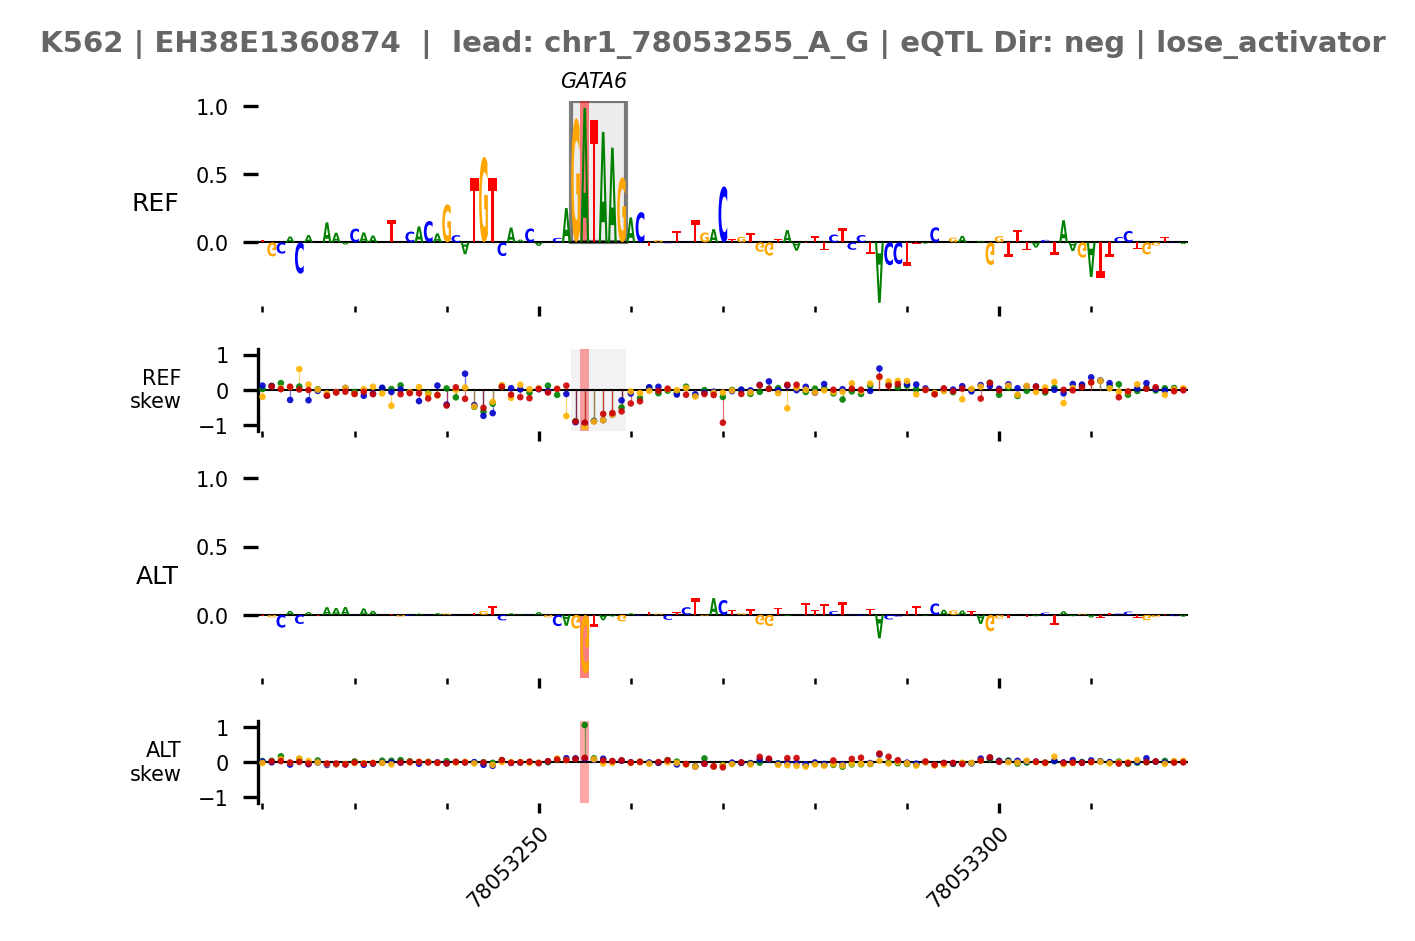

In [50]:
plot_single_enhancers(
    'k562',
    k562_ConcDict4plotting['EH38E1360874_chr1_78053255_A_G'],
    'concordant',
    'EH38E1360874_chr1_78053255_A_G',
    include_lollipop=True,
    plot_range=(78053220, 78053320),
    compact=True,
    output_format='pdf'
)

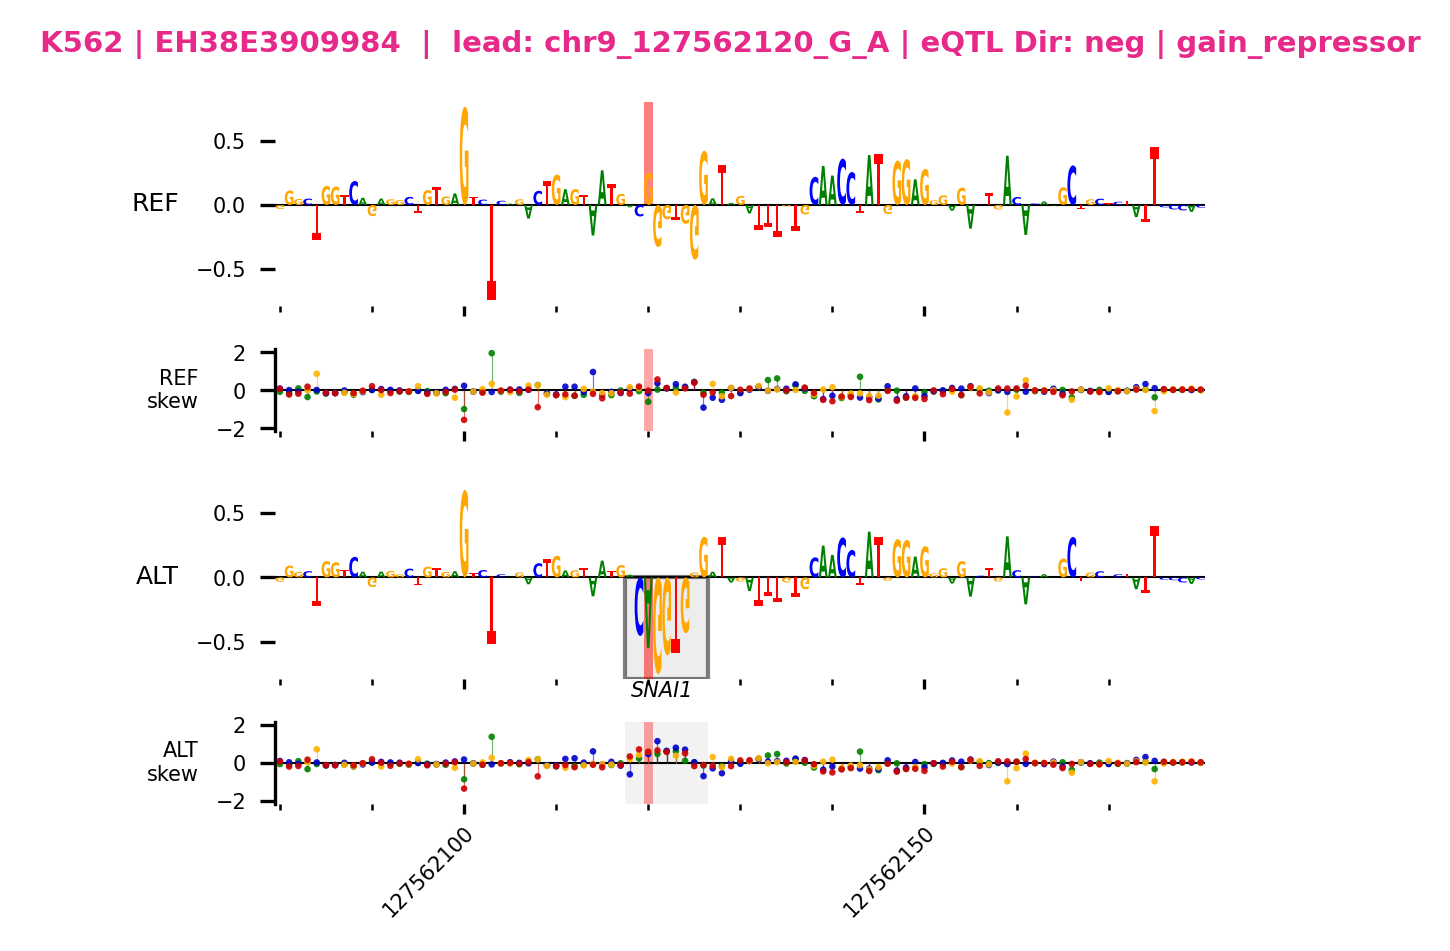

In [45]:
plot_single_enhancers(
    'k562',
    k562_ConcDict4plotting['EH38E3909984_chr9_127562120_G_A'],
    'concordant',
    'EH38E3909984_chr9_127562120_G_A',
    include_lollipop=True,
    plot_range=(127562080, 127562180),
    compact=True,
    output_format='pdf'
)

In [ ]:
# open full predictions for making bar plots of skew for example variants
allPreds = pd.read_csv('../processed_data/alt_background_sat_mut/processed_data/all_predictions_with_background.tsv.gz', sep = '\t')

In [56]:
# make a bar plot of the skew of that variant
chr1_78053255_A_G_Preds = allPreds[(allPreds['chrom'] == 'chr1') &
                                   (allPreds['pos'] == 78053255) &
                                   (allPreds['ref'] == 'A') &
                                   (allPreds['alt'] == 'G')]
chr1_78053255_A_G_Ref = chr1_78053255_A_G_Preds['k562_ref_pred'].tolist()[0]
chr1_78053255_A_G_Alt = chr1_78053255_A_G_Preds['k562_alt_pred'].tolist()[0]
chr1_78053255_A_G_Palette = {
    'A' : '#0F8140',
    'G' : '#FAA51A'
}

In [57]:
chr1_78053255_A_G_Preds

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred
14813674,chr1,78053255,EH38E1360874_REF,A,G,1.025027,-0.034782,-1.059809,0.046774,-0.044136,-0.09091,-0.265412,-0.418634,-0.153222


In [59]:
# make a bar plot of the skew of that variant
chr9_127562120_G_A_Preds = allPreds[(allPreds['chrom'] == 'chr9') &
                                    (allPreds['pos'] == 127562120) &
                                    (allPreds['ref'] == 'G') &
                                    (allPreds['alt'] == 'A')]
chr9_127562120_G_A_Ref = chr9_127562120_G_A_Preds['k562_ref_pred'].tolist()[0]
chr9_127562120_G_A_Alt = chr9_127562120_G_A_Preds['k562_alt_pred'].tolist()[0]

In [60]:
chr9_127562120_G_A_Preds

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred
20808699,chr9,127562120,EH38E3909984_REF,G,A,3.667336,3.066599,-0.600737,2.926864,2.461374,-0.465489,3.261308,2.212995,-1.048313


/tmp/ipykernel_2553994/2918464712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2553994/2918464712.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


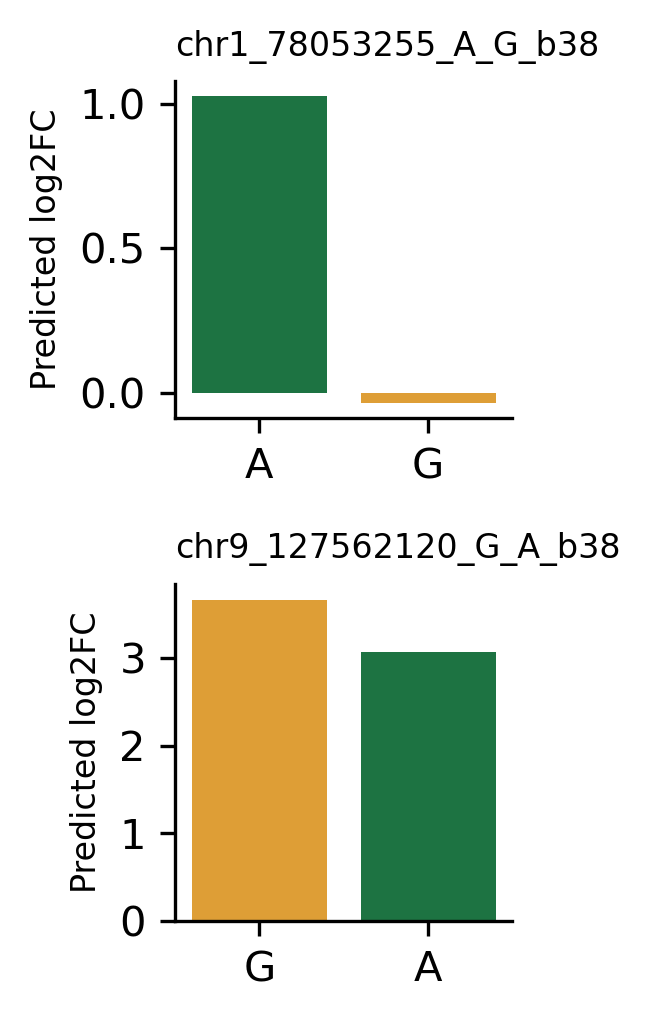

In [101]:
f = plt.figure(figsize=(2,3.5),dpi=300)
gs = f.add_gridspec(2,1)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# chr1_78053255_A_G #
with sns.axes_style():
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_box_aspect(1)
    sns.barplot(
        x = ['A', 'G'],
        y = [chr1_78053255_A_G_Ref, chr1_78053255_A_G_Alt],
        palette = chr1_78053255_A_G_Palette
    )
    ax_01.set_title('chr1_78053255_A_G_b38', fontsize = 8, loc='left')
    ax_01.set_ylabel('Predicted log2FC', fontsize = 8)
with sns.axes_style():
    ax_02 = f.add_subplot(gs[1,0])
    ax_02.set_box_aspect(1)
    sns.barplot(
        x = ['G', 'A'],
        y = [chr9_127562120_G_A_Ref, chr9_127562120_G_A_Alt],
        palette = chr1_78053255_A_G_Palette
    )
    ax_02.set_title('chr9_127562120_G_A_b38', fontsize = 8, loc='left')
    ax_02.set_ylabel('Predicted log2FC', fontsize = 8)
sns.despine()
plt.tight_layout()
plt.savefig('singlePlots/gtex_mechanism_example_bar_plots.pdf', dpi=300)